<h1 style="text-align: center; font-weight: bold;">PROYECTO DE MODELO ORIGINAL</h1>






<div style="text-align: center;">
 Autores: Laima Guatecique & Juan David Urbina de La Ossa
</div>

## **1. Introducción**

El mercado de divisas (FOREX) se caracteriza por su alta liquidez, operación continua y elevada volatilidad, influenciada por factores económicos, políticos y sociales, lo que lo convierte en un sistema complejo de analizar. Este mercado opera las veinticuatro horas del día, iniciando en Sídney y trasladándose progresivamente a centros financieros como Tokio, Londres y Nueva York, permitiendo a los inversores reaccionar en tiempo real ante fluctuaciones en los tipos de cambio (García Figal & de la Oliva de Con, 2021). Las divisas se negocian en pares, como el EUR/USD (euro frente al dólar), donde la primera moneda se denomina base y la segunda su contraparte, siendo el precio expresado en función de la divisa base. En este contexto, el presente estudio se centra en el periodo 2002–2020, analizando el comportamiento del par EUR/USD e incorporando eventos clave como la crisis financiera de 2008 y la pandemia del COVID-19, los cuales incrementaron significativamente la incertidumbre y volatilidad en los mercados. Las variaciones en las tasas de cambio responden no solo a eventos macroeconómicos, sino también a factores políticos y externos como desastres naturales o crisis globales, lo que resalta la importancia de su análisis. Asimismo, las cotizaciones del mercado FOREX resultan fundamentales tanto para inversionistas privados como para los Estados, que participan activamente en estos mercados con el objetivo de fortalecer sus economías y posicionar sus monedas a nivel internacional; en el caso de Colombia, por ejemplo, los fondos privados de pensiones, bajo el Decreto 2955 de 2010 (Corredor & Montoya, 2022), pueden invertir en estos mercados como estrategia de crecimiento. No obstante, la alta volatilidad también implica riesgos significativos para quienes realizan operaciones de trading. En este marco, el artículo busca, a partir del uso de distintas técnicas, analizar el comportamiento del par EUR/USD y generar un pronóstico de su tendencia futura, considerando variables fundamentadas en evidencia empírica tanto nacional como internacional.

A partir de un análisis exploratorio de datos (EDA), se busca identificar patrones y características relevantes de la serie temporal. Se analiza la tendencia para entender la dirección del mercado y la volatilidad como medida del riesgo e inestabilidad en los precios.

Finalmente, el análisis temporal permite estudiar la dependencia entre observaciones, incluyendo patrones como estacionalidad y ciclos, proporcionando una visión integral del comportamiento del mercado y una base para futuros análisis predictivos.

## **2. Análisis exploratorio de datos**


In [61]:
import tensorflow as tf


In [1]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("imetomi/eur-usd-forex-pair-historical-data-2002-2019")

print("Path to dataset files:", path)

c:\Users\planeacion\miniconda3\envs\ml_venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\planeacion\.cache\kagglehub\datasets\imetomi\eur-usd-forex-pair-historical-data-2002-2019\versions\2


In [2]:

for file in os.listdir(path):
    print(file)

eurusd_hour.csv
eurusd_minute.csv
eurusd_news.csv


La base de datos se obtiene desde Kaggle mediante su API, permitiendo la descarga automatizada de información del par EUR/USD. El conjunto incluye datos con diferentes niveles de granularidad (por minuto y por hora), así como una base complementaria de noticias relacionadas con la tasa de cambio.

El entorno de trabajo se configura en Python 3.9, donde se importan librerías para el manejo de datos, utilidades del sistema y TensorFlow, este último reservado para un uso posterior en tareas de predicción. Posteriormente, se realiza la descarga del dataset correspondiente al periodo 2002–2020 y se listan los archivos disponibles con el fin de reconocer su estructura y definir la granularidad a utilizar en el análisis.

### **2.1. Formato de serie de tiempo para la base de datos**

In [4]:
import pandas as pd

df = pd.read_csv(os.path.join(path, "eurusd_minute.csv"))
print(df.head(10))
print(df.shape)

         Date   Time      BO      BH      BL      BC     BCh      AO      AH  \
0  2005-01-02  18:29  1.3555  1.3555  1.3555  1.3555  0.0000  1.3565  1.3565   
1  2005-01-02  18:38  1.3555  1.3555  1.3555  1.3555  0.0000  1.3565  1.3565   
2  2005-01-02  18:51  1.3562  1.3562  1.3562  1.3562  0.0000  1.3572  1.3572   
3  2005-01-02  18:52  1.3560  1.3560  1.3560  1.3560  0.0000  1.3570  1.3570   
4  2005-01-02  18:55  1.3563  1.3563  1.3563  1.3563  0.0000  1.3573  1.3573   
5  2005-01-02  18:57  1.3562  1.3562  1.3562  1.3562  0.0000  1.3572  1.3572   
6  2005-01-02   19:4  1.3564  1.3564  1.3564  1.3564  0.0000  1.3574  1.3574   
7  2005-01-02   19:7  1.3565  1.3565  1.3564  1.3564  0.0001  1.3575  1.3575   
8  2005-01-02  19:10  1.3564  1.3564  1.3564  1.3564  0.0000  1.3574  1.3574   
9  2005-01-02  19:12  1.3564  1.3564  1.3564  1.3564  0.0000  1.3574  1.3574   

       AL      AC     ACh  
0  1.3565  1.3565  0.0000  
1  1.3565  1.3565  0.0000  
2  1.3572  1.3572  0.0000  
3  1.35

In [5]:
print(df.columns.tolist())
print(df.dtypes)
print(df.head())
print('No. of rows, columns:', df.shape)

['Date', 'Time', 'BO', 'BH', 'BL', 'BC', 'BCh', 'AO', 'AH', 'AL', 'AC', 'ACh']
Date     object
Time     object
BO      float64
BH      float64
BL      float64
BC      float64
BCh     float64
AO      float64
AH      float64
AL      float64
AC      float64
ACh     float64
dtype: object
         Date   Time      BO      BH      BL      BC  BCh      AO      AH  \
0  2005-01-02  18:29  1.3555  1.3555  1.3555  1.3555  0.0  1.3565  1.3565   
1  2005-01-02  18:38  1.3555  1.3555  1.3555  1.3555  0.0  1.3565  1.3565   
2  2005-01-02  18:51  1.3562  1.3562  1.3562  1.3562  0.0  1.3572  1.3572   
3  2005-01-02  18:52  1.3560  1.3560  1.3560  1.3560  0.0  1.3570  1.3570   
4  2005-01-02  18:55  1.3563  1.3563  1.3563  1.3563  0.0  1.3573  1.3573   

       AL      AC  ACh  
0  1.3565  1.3565  0.0  
1  1.3565  1.3565  0.0  
2  1.3572  1.3572  0.0  
3  1.3570  1.3570  0.0  
4  1.3573  1.3573  0.0  
No. of rows, columns: (5618819, 12)


In [6]:
import warnings
warnings.filterwarnings("ignore")

In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt


Se importan las librerías necesarias para el análisis, entre ellas pandas, numpy, seaborn y matplotlib. Pandas se utiliza para la manipulación del DataFrame (filtrar, agrupar, limpiar y transformar datos), numpy para realizar cálculos numéricos eficientes, seaborn para la visualización estadística con diseños simplificados y matplotlib para un control más detallado de las gráficas.

Posteriormente, se carga la base de datos mediante pd.read_csv, se inspeccionan las primeras observaciones con df.head() y se revisan sus dimensiones con df.shape. Asimismo, se examinan los nombres de las columnas con df.columns.tolist() y los tipos de datos con df.dtypes, permitiendo un reconocimiento inicial de la estructura del dataset.

Finalmente, se selecciona la base de datos con frecuencia por minuto, ya que ofrece una mayor cantidad de observaciones, lo que permite un análisis más detallado y preciso del comportamiento del par EUR/USD.

### **2.2. Descripción y definición de la variables** 

In [10]:
sns.set_style("darkgrid")

| Variable | Descripción |
|:--------:|:------------|
| **Time** | Hora en que se midió el precio |
| **BO** | Precio de apertura Bid<sup>1</sup> |
| **BH** | Precio más alto en el período Bid |
| **BL** | Precio más bajo en el período Bid |
| **BC** | Precio de cierre Bid |
| **BCh** | Cambio entre apertura y cierre Bid |
| **AO** | Precio de apertura Ask<sup>2</sup> |
| **AH** | Precio más alto en el período Ask |
| **AL** | Precio más bajo en el período Ask |

<sup>1</sup> **Bid** — Precio al que el mercado compra (perspectiva del vendedor).  
<sup>2</sup> **Ask** — Precio al que el mercado vende (perspectiva del comprador).

&bullet; No hay presencia de valores faltantes en el dataset

In [11]:
df.isna().sum()


Date    0
Time    0
BO      0
BH      0
BL      0
BC      0
BCh     0
AO      0
AH      0
AL      0
AC      0
ACh     0
dtype: int64

In [9]:
# Combinar Date y Time para la el horario exacto
df_time = df.copy()

if 'Date' in df_time.columns and 'Time' in df_time.columns:
    df_time['Datetime'] = pd.to_datetime(df_time['Date'] + ' ' + df_time['Time'])
    df_time = df_time.set_index('Datetime')
    df_time = df_time.drop(columns=['Date', 'Time'])
    df_time = df_time.sort_index()

print(df_time.head())
print(df_time.shape)



                         BO      BH      BL      BC  BCh      AO      AH  \
Datetime                                                                   
2005-01-02 18:29:00  1.3555  1.3555  1.3555  1.3555  0.0  1.3565  1.3565   
2005-01-02 18:38:00  1.3555  1.3555  1.3555  1.3555  0.0  1.3565  1.3565   
2005-01-02 18:51:00  1.3562  1.3562  1.3562  1.3562  0.0  1.3572  1.3572   
2005-01-02 18:52:00  1.3560  1.3560  1.3560  1.3560  0.0  1.3570  1.3570   
2005-01-02 18:55:00  1.3563  1.3563  1.3563  1.3563  0.0  1.3573  1.3573   

                         AL      AC  ACh  
Datetime                                  
2005-01-02 18:29:00  1.3565  1.3565  0.0  
2005-01-02 18:38:00  1.3565  1.3565  0.0  
2005-01-02 18:51:00  1.3572  1.3572  0.0  
2005-01-02 18:52:00  1.3570  1.3570  0.0  
2005-01-02 18:55:00  1.3573  1.3573  0.0  
(5618819, 10)


In [11]:
df_5m = df_time.resample('5T').median().dropna()

print(df_5m.shape)
print(df_5m.head())
print(df_5m.tail() )

(1153890, 10)
                          BO       BH       BL       BC  BCh       AO  \
Datetime                                                                
2005-01-02 18:25:00  1.35550  1.35550  1.35550  1.35550  0.0  1.35650   
2005-01-02 18:35:00  1.35550  1.35550  1.35550  1.35550  0.0  1.35650   
2005-01-02 18:50:00  1.35610  1.35610  1.35610  1.35610  0.0  1.35710   
2005-01-02 18:55:00  1.35625  1.35625  1.35625  1.35625  0.0  1.35725   
2005-01-02 19:00:00  1.35640  1.35640  1.35640  1.35640  0.0  1.35740   

                          AH       AL       AC  ACh  
Datetime                                             
2005-01-02 18:25:00  1.35650  1.35650  1.35650  0.0  
2005-01-02 18:35:00  1.35650  1.35650  1.35650  0.0  
2005-01-02 18:50:00  1.35710  1.35710  1.35710  0.0  
2005-01-02 18:55:00  1.35725  1.35725  1.35725  0.0  
2005-01-02 19:00:00  1.35740  1.35740  1.35740  0.0  
                           BO       BH        BL       BC       BCh       AO  \
Datetime        

Dado que el objetivo es analizar la base de datos en términos de patrones temporales, es necesario estructurarla como una serie de tiempo. Para ello, se utilizan las variables Date y Time, donde la primera corresponde a la fecha y la segunda al minuto de registro; sin embargo, debido a que los datos no se encuentran de forma estrictamente secuencial minuto a minuto, se realiza una transformación a intervalos de 5 minutos con el fin de obtener una serie más consistente. Este proceso se lleva a cabo mediante una técnica de remuestreo, utilizando la mediana como medida de agregación para reducir el efecto de valores atípicos. Finalmente, la variable principal de análisis en esta sección exploratoria es el precio de cierre Bid (BC), el cual representa el precio desde la perspectiva de venta. Para ello, se procede a construir una variable de tipo fecha-hora unificada, combinando las columnas Date y Time mediante la función pd.to_datetime(). Posteriormente, esta nueva variable se establece como índice del DataFrame utilizando set_index(), lo que permite organizar los datos en función del tiempo. A continuación, se eliminan las columnas originales y se ordena la información cronológicamente con sort_index().

### **2.3. Análisis de volatilidad, el precio de cierre Bid, y los retornos**

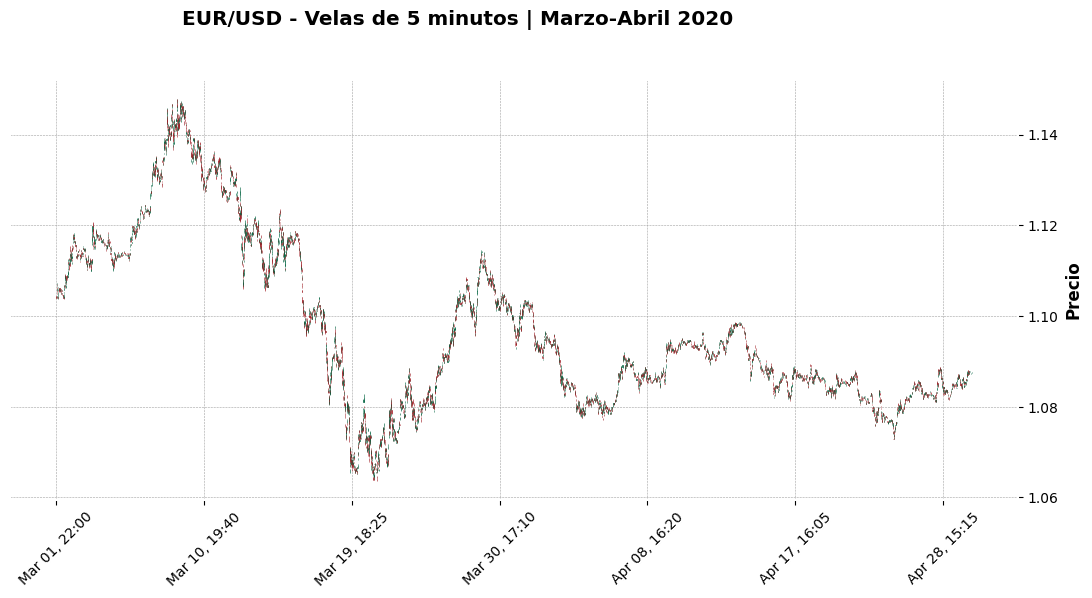

In [12]:
import mplfinance as mpf

df_plot = df_5m['2020-03-01':'2020-04-29'].copy()

df_plot = df_plot.rename(columns={
    'BO': 'Open',
    'BH': 'High',
    'BL': 'Low',
    'BC': 'Close'
})

mpf.plot(df_plot[['Open', 'High', 'Low', 'Close']],
         type='candle',
         style='charles',
         title='EUR/USD - Velas de 5 minutos | Marzo-Abril 2020',
         ylabel='Precio',
         figsize=(14, 6))

Se utiliza la librería mplfinance para la construcción de un gráfico de velas japonesas del par EUR/USD. En primer lugar, se filtra el DataFrame a un rango de fechas específico de interés para el análisis. Posteriormente, las columnas son renombradas al formato estándar OHLC (Open, High, Low, Close), requerido por la librería para la correcta visualización. Finalmente, mediante la función mpf.plot(), se genera el gráfico tipo candle, empleando el estilo charles y ajustando parámetros visuales como el título y el tamaño de la figura, lo que permite una representación clara del comportamiento del precio en el tiempo.

A partir de esta visualización, se identifican distintas fases en la evolución del tipo de cambio durante el periodo analizado. En la Fase 1 (1–9 de marzo), se observa un rally del euro, donde el EUR/USD aumenta aproximadamente de 1.101 a 1.149, impulsado por la percepción inicial de que la pandemia afectaría más a Estados Unidos, debilitando al dólar. En la Fase 2 (9–20 de marzo), ocurre una caída abrupta del par hasta cerca de 1.064, fenómeno conocido como “dollar dash”, donde la demanda global de liquidez en dólares se dispara ante el pánico financiero. Posteriormente, en la Fase 3 (20–30 de marzo), se presenta un rebote hasta niveles cercanos a 1.114, asociado a la rápida intervención de la Reserva Federal mediante reducción de tasas, provisión de liquidez y líneas de swap internacionales. En la Fase 4 (30 de marzo–6 de abril), se evidencia una nueva presión bajista sobre el euro, aunque más moderada, relacionada con la incertidumbre sobre la respuesta fiscal en la zona euro. Finalmente, en la Fase 5 (6–29 de abril), el tipo de cambio entra en una etapa de consolidación en un rango estrecho entre 1.083 y 1.092, reflejando un mercado en espera ante la incertidumbre económica global.

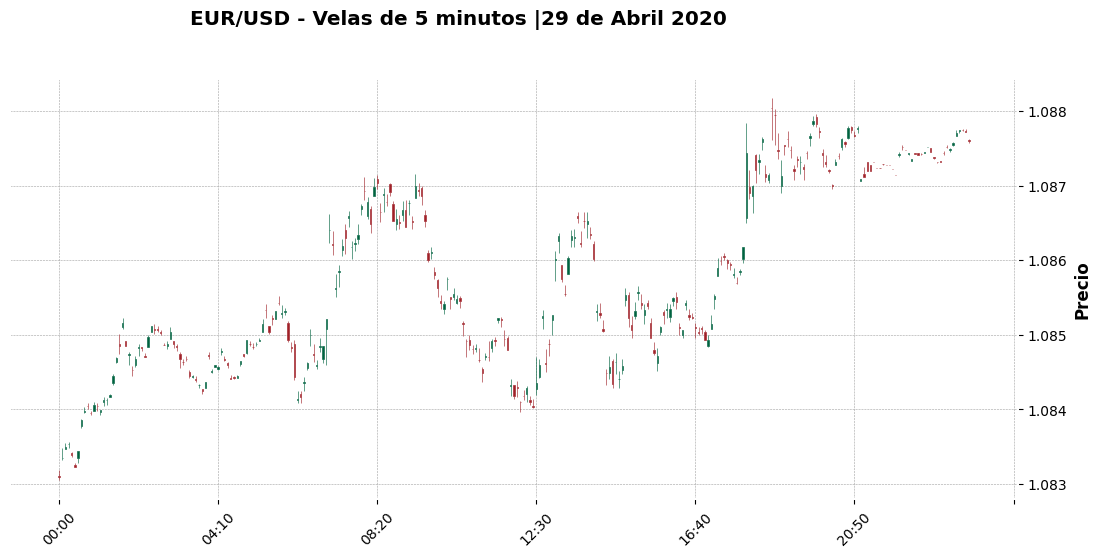

In [13]:
df_plot = df_5m.loc['2020-04-29'].copy()
df_plot = df_plot.rename(columns={
    'BO': 'Open',
    'BH': 'High',
    'BL': 'Low',
    'BC': 'Close'
})

mpf.plot(df_plot[['Open', 'High', 'Low', 'Close']],
         type='candle',
         style='charles',
         title='EUR/USD - Velas de 5 minutos |29 de Abril 2020',
         ylabel='Precio',
         figsize=(14, 6))

Este día fue particularmente interesante porque coincidió con la reunión del FOMC de la Reserva Federal (Welle, 2020). La estructura del gráfico lo refleja con claridad.
La jornada arrancó débil en la sesión asiática, oscilando sin convicción alrededor de 1.083, zona que había funcionado como soporte en días anteriores. Sin noticias que muevan el mercado, el volumen es bajo y las velas son pequeñas, lo que se ve claramente en la parte izquierda del gráfico.
Al abrir Europa (~08:20), el impulso alcista es el movimiento más nítido del día. Ese miércoles se publicaron datos preliminares del PIB de la zona euro del primer trimestre de 2020, que aunque eran negativos (contracción del −3.8%), estaban en línea o ligeramente mejor de lo esperado. En forex, "menos malo de lo esperado" es suficiente para un rally del euro.
El pullback de las 12:30 coincide con la ventana de datos americanos pre-apertura de Nueva York: ese día se conoció el PIB avance de EE.UU. del Q1 (−4.8%), que sorprendió negativamente, pero también datos de empleo privado ADP que generaron volatilidad en ambas direcciones antes de que el mercado digiriera la información.
El máximo del día cerca de las 16:40–17:00 UTC es el evento más significativo: la Fed confirmó que mantendría tasas en cero y expandiría su balance sin límites. Las líneas de swap con el BCE seguían activas. Esa señal de "whatever it takes" americana debilitó al dólar y empujó al EUR/USD a su nivel más alto de la jornada.
En conjunto, el día muestra un sesgo alcista estructural con dos impulsos claros separados por una corrección técnica, un patrón típico de días con eventos macro importantes donde el mercado primero reacciona, luego duda, y finalmente retoma la dirección dominante.

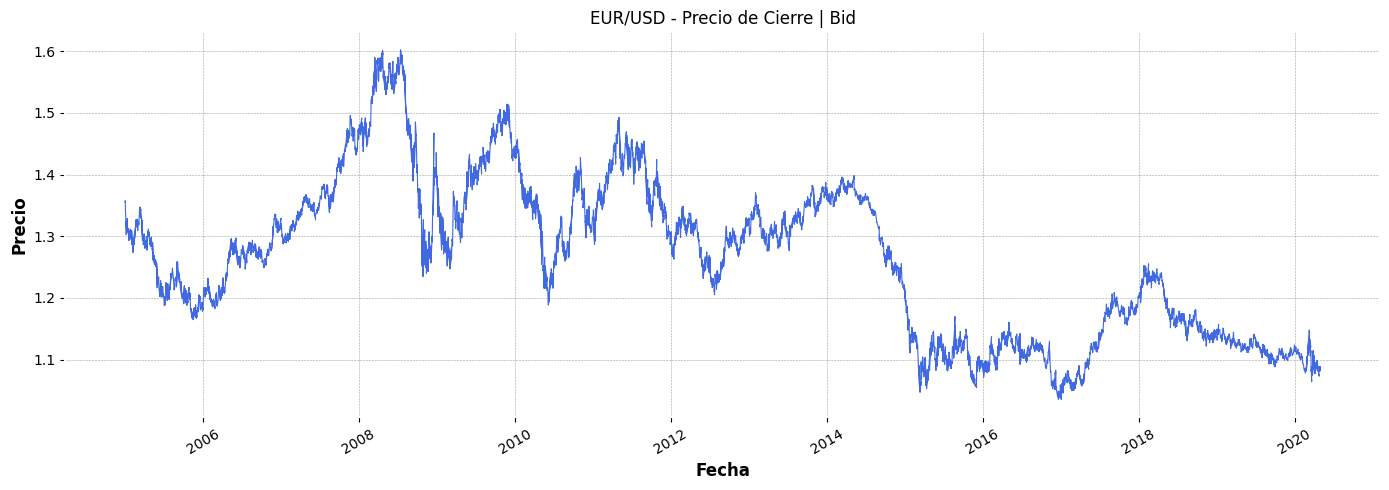

In [14]:

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))
plt.plot(df_5m.index, df_5m['BC'], color='royalblue', linewidth=0.8)
plt.title('EUR/USD - Precio de Cierre | Bid')
plt.xlabel('Fecha')
plt.ylabel('Precio')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Lo más importante que muestra esta gráfica es que el EUR/USD vivió dos regímenes completamente distintos separados por el año 2014. Antes de 2014 el par operaba en una banda alta, entre 1.20 y 1.60, con alta volatilidad pero con el euro en una posición de relativa fortaleza, en un contexto donde la política monetaria expansiva de la Reserva Federal debilitaba estructuralmente al dólar. Después de 2014 el escenario se invierte de forma clara: el Banco Central Europeo (BCE) toma un rol más activo con políticas expansivas como el quantitative easing, mientras la Fed inicia un proceso de normalización, generando una divergencia monetaria que presiona al euro a la baja. La caída abrupta entre 2014 y 2015 refleja no solo un ajuste de mercado, sino un reposicionamiento global de portafolios institucionales hacia estrategias de dólar fuerte. Este cambio también se enmarca en un contexto de cuestionamientos estructurales sobre la solidez de la zona euro; como señaló Mario Draghi (2014), la unión monetaria europea aún no estaba completamente consolidada y requería condiciones institucionales y económicas más robustas para garantizar su estabilidad y permanencia. La ausencia de mecanismos fiscales comunes y la necesidad de una mayor integración financiera generaban incertidumbre sobre la capacidad de respuesta ante choques económicos, lo que afectaba la percepción del euro como moneda de reserva (European Central Bank, 2014). A partir de entonces, aunque se presentan intentos de recuperación como el de 2017–2018, el par no logra retornar de forma sostenida a sus niveles previos, cerrando en 2020 en un entorno de debilidad relativa del euro, lo que evidencia un cambio estructural en la dinámica del mercado, donde la política monetaria y la credibilidad institucional juegan un papel determinante.

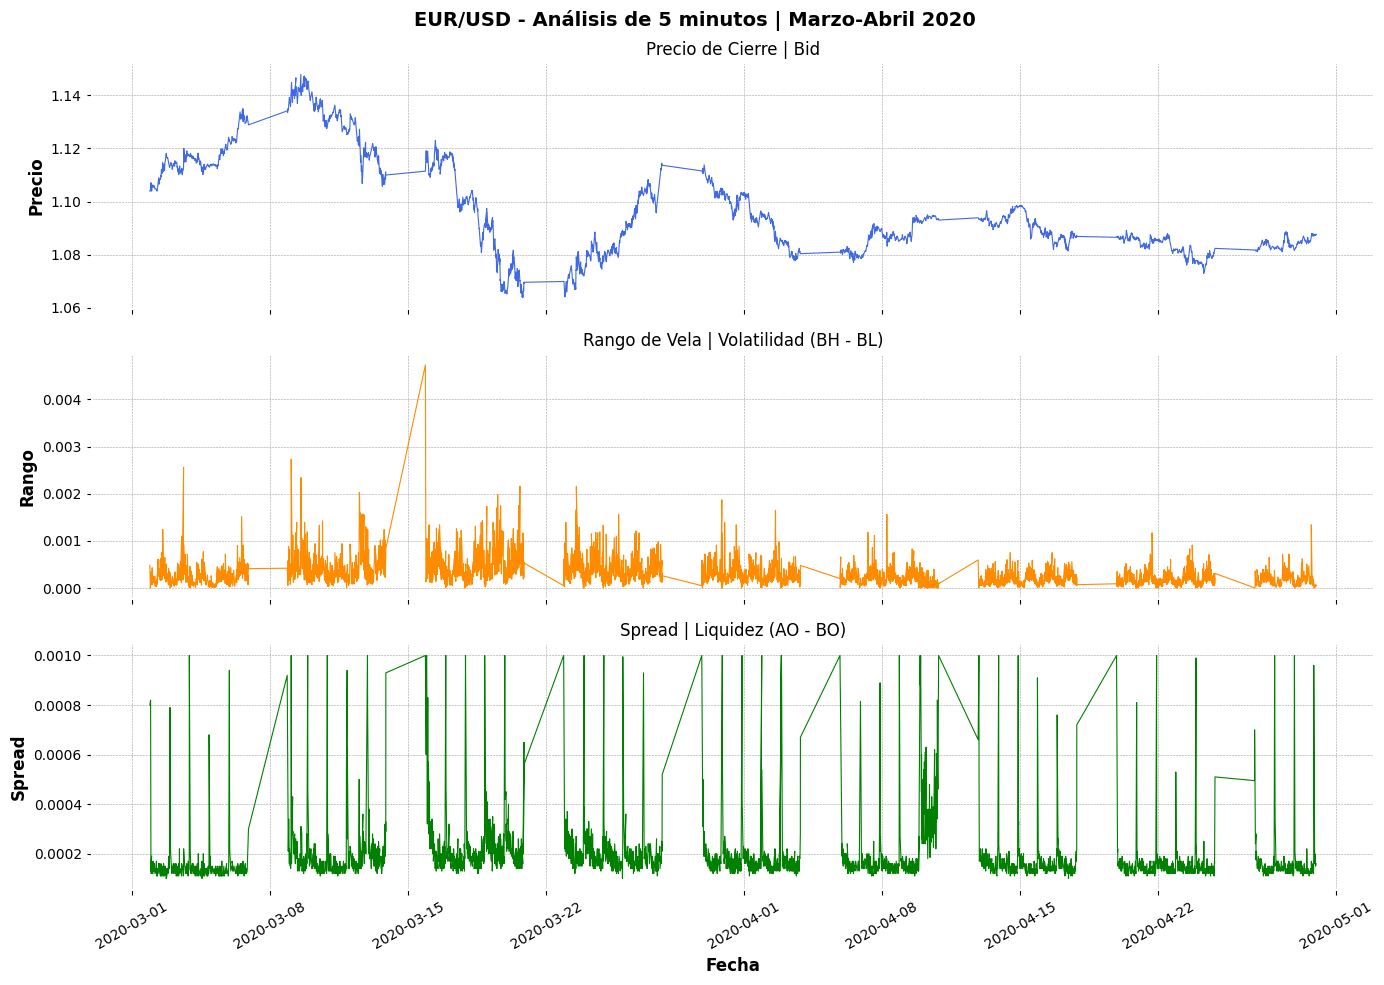

In [15]:
import matplotlib.pyplot as plt

df_plot = df_5m['2020-03-01':'2020-04-29'].copy()
df_plot['Rango'] = df_plot['BH'] - df_plot['BL']
df_plot['Spread'] = df_plot['AO'] - df_plot['BO']

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Precio de cierre
axes[0].plot(df_plot.index, df_plot['BC'], color='royalblue', linewidth=0.8)
axes[0].set_title('Precio de Cierre | Bid')
axes[0].set_ylabel('Precio')

# Rango
axes[1].plot(df_plot.index, df_plot['Rango'], color='darkorange', linewidth=0.8)
axes[1].set_title('Rango de Vela | Volatilidad (BH - BL)')
axes[1].set_ylabel('Rango')

# Spread
axes[2].plot(df_plot.index, df_plot['Spread'], color='green', linewidth=0.8)
axes[2].set_title('Spread | Liquidez (AO - BO)')
axes[2].set_ylabel('Spread')
axes[2].set_xlabel('Fecha')

plt.suptitle('EUR/USD - Análisis de 5 minutos | Marzo-Abril 2020', fontsize=14)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

El gráfico presenta tres paneles apilados verticalmente, todos compartiendo el mismo eje temporal que va de marzo a abril de 2020, con velas de 5 minutos. Antes de graficar se derivaron dos métricas a partir de los datos crudos: el Rango de vela, calculado como la diferencia entre el precio máximo Bid (BH) y el precio mínimo Bid (BL) de cada período, que captura cuánto se movió el precio dentro de esa vela; y el Spread, calculado como la diferencia entre el precio de apertura Ask (AO) y el precio de apertura Bid (BO), que refleja el costo de transacción y sirve como proxy de liquidez del mercado en cada momento.
El primer panel muestra el precio de cierre Bid, referencia principal del movimiento del par. El segundo panel muestra el Rango (BH menos BL), que mide la volatilidad vela a vela. El tercer panel muestra el Spread (AO menos BO), que mide la liquidez disponible en cada instante.

Durante la semana del 15 al 20 de marzo, cuando el precio desploma de 1.10 a 1.064, el panel de volatilidad muestra el pico más alto de todo el período, con rangos de vela que llegan a 0.004, entre cuatro y cinco veces el nivel normal. En esas velas de 5 minutos el precio se movía tanto como lo haría en horas enteras durante un día tranquilo. Al mismo tiempo el spread se dispara a sus máximos absolutos, superando 0.0009, lo que indica que los creadores de mercado ampliaban su margen de protección ante la incertidumbre extrema. El mercado no solo caía rápido sino que lo hacía en condiciones de muy baja liquidez, lo que amplificaba cada movimiento.
Después del rebote de finales de marzo, los tres paneles se comportan de forma mucho más ordenada. El precio consolida entre 1.08 y 1.10, la volatilidad regresa a niveles cercanos a los de principios de marzo, y el spread se normaliza alrededor de 0.0002, su nivel habitual en condiciones de mercado líquido.

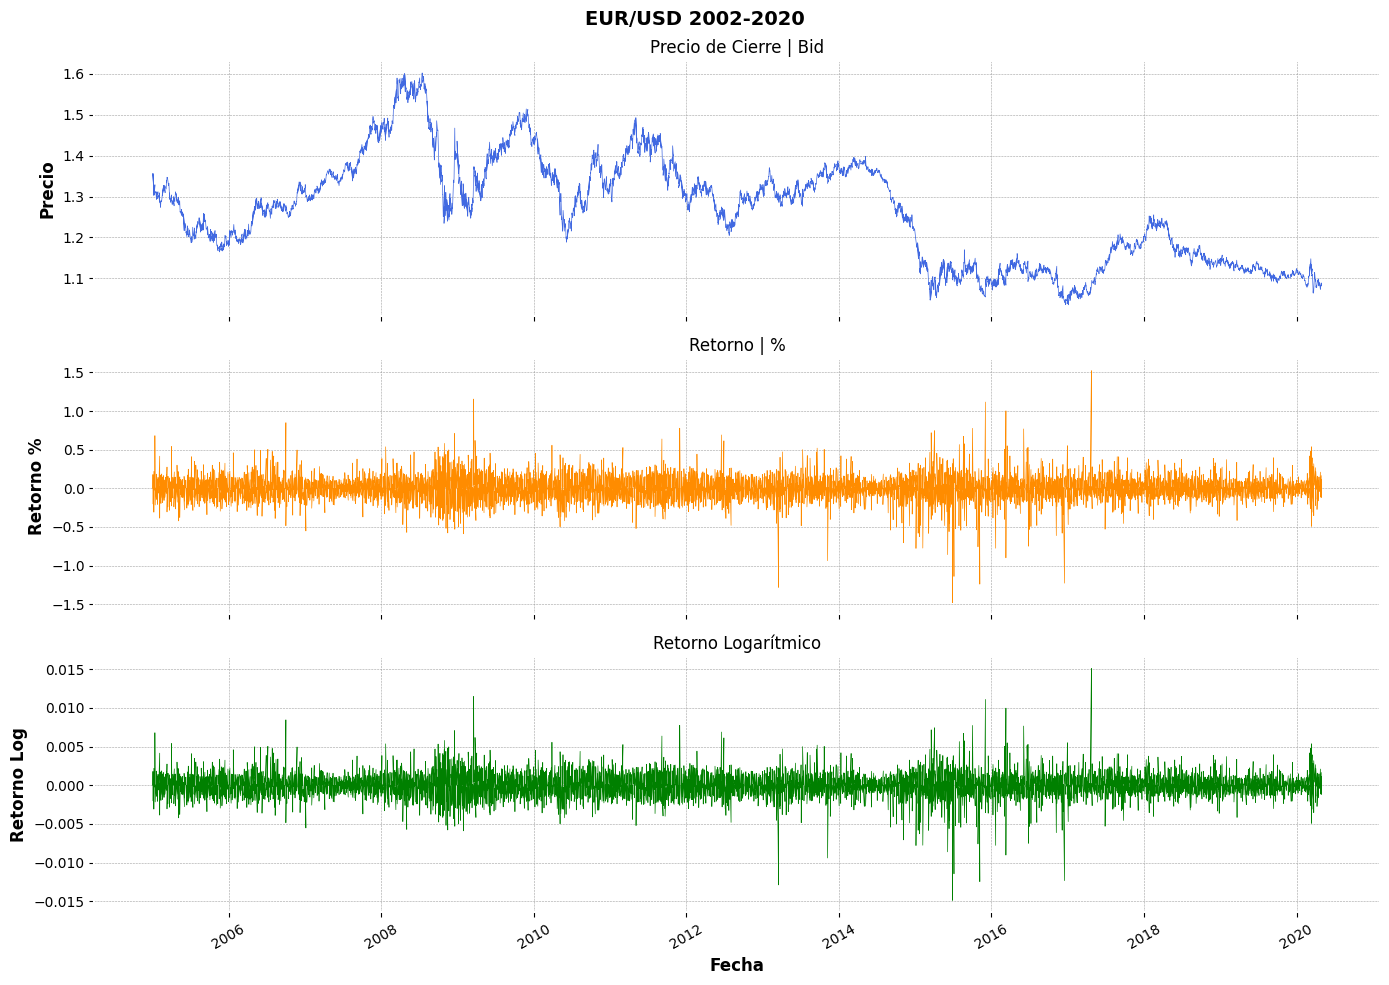

In [16]:
df_5m['Retorno'] = df_5m['BC'].pct_change() * 100
df_5m['Retorno_log'] = np.log(df_5m['BC'] / df_5m['BC'].shift(1))

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Precio de cierre
axes[0].plot(df_5m.index, df_5m['BC'], color='royalblue', linewidth=0.5)
axes[0].set_title('Precio de Cierre | Bid')
axes[0].set_ylabel('Precio')

# Retorno %
axes[1].plot(df_5m.index, df_5m['Retorno'], color='darkorange', linewidth=0.5)
axes[1].set_title('Retorno | %')
axes[1].set_ylabel('Retorno %')

# Retorno logarítmico
axes[2].plot(df_5m.index, df_5m['Retorno_log'], color='green', linewidth=0.5)
axes[2].set_title('Retorno Logarítmico')
axes[2].set_ylabel('Retorno Log')
axes[2].set_xlabel('Fecha')

plt.suptitle('EUR/USD 2002-2020', fontsize=14)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Se calculan dos tipos de retorno: pct_change() permite obtener el retorno porcentual simple entre cada observación, mientras que np.log(BC / BC.shift(1)) calcula el retorno logarítmico desplazando el precio un período hacia atrás. Posteriormente, se grafican las tres series en un panel de tres subgráficos apilados, mostrando el precio de cierre, el retorno porcentual y el retorno logarítmico a lo largo del periodo 2005–2020.

A nivel general, el precio de cierre evidencia cambios estructurales importantes, especialmente alrededor de 2014, donde el EUR/USD pasa de un régimen alto a uno más bajo y estable. Por su parte, los retornos (tanto simples como logarítmicos) oscilan alrededor de cero, pero presentan picos pronunciados en periodos de crisis, lo que indica episodios de alta volatilidad. Asimismo, se observa agrupamiento de volatilidad, donde periodos tranquilos son seguidos por fases de mayor incertidumbre, lo que sugiere que la varianza no es constante en el tiempo. En conjunto, estos resultados evidencian que, aunque el precio no es estacionario, los retornos sí presentan propiedades más adecuadas para el análisis temporal y modelación.

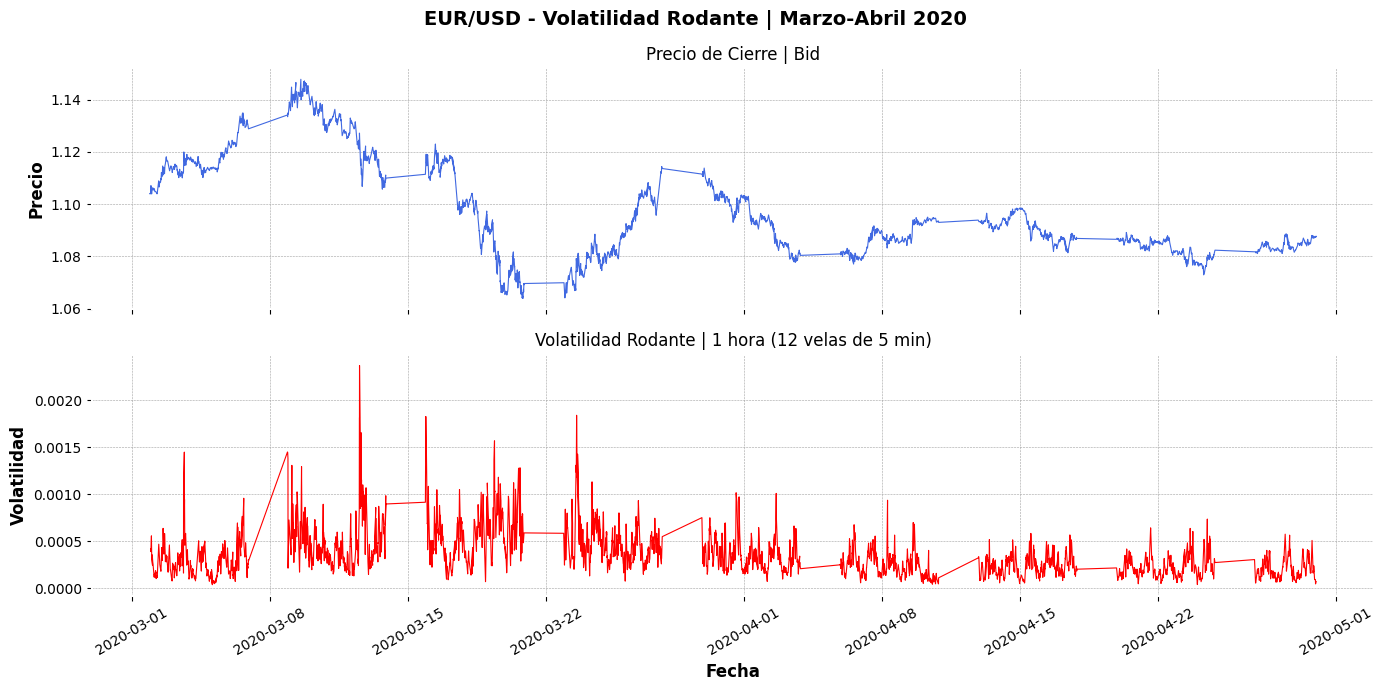

In [17]:
df_plot = df_5m['2020-03-01':'2020-04-29'].copy()
df_plot['Retorno_log'] = np.log(df_plot['BC'] / df_plot['BC'].shift(1))
df_plot['Volatilidad'] = df_plot['Retorno_log'].rolling(window=12).std()

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# Precio de cierre
axes[0].plot(df_plot.index, df_plot['BC'], color='royalblue', linewidth=0.8)
axes[0].set_title('Precio de Cierre | Bid')
axes[0].set_ylabel('Precio')

# Volatilidad
axes[1].plot(df_plot.index, df_plot['Volatilidad'], color='red', linewidth=0.8)
axes[1].set_title('Volatilidad Rodante | 1 hora (12 velas de 5 min)')
axes[1].set_ylabel('Volatilidad')
axes[1].set_xlabel('Fecha')

plt.suptitle('EUR/USD - Volatilidad Rodante | Marzo-Abril 2020', fontsize=14)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Para analizar la volatilidad en un periodo específico, se filtra la base de datos entre el 1 de marzo y el 29 de abril de 2020. A partir de esta submuestra, se calcula el retorno logarítmico mediante la expresión np.log(BC / BC.shift(1)), lo que permite medir las variaciones relativas del precio de forma más adecuada para análisis financiero. Posteriormente, se estima la volatilidad rodante aplicando una ventana móvil de 12 periodos (rolling(window=12).std()), equivalente a 1 hora dado que los datos están en intervalos de 5 minutos. Finalmente, se construyen dos gráficos apilados: el primero muestra la evolución del precio de cierre (Bid), y el segundo la volatilidad en el tiempo.

En cuanto a la interpretación, el gráfico evidencia claramente el impacto del shock del COVID-19 en los mercados financieros. Durante la primera mitad de marzo se observa un incremento significativo en la volatilidad, con picos pronunciados que reflejan episodios de alta incertidumbre y movimientos abruptos en el tipo de cambio. Este comportamiento coincide con el periodo del “dollar dash”, donde la demanda global de liquidez en dólares generó fuertes fluctuaciones. A medida que avanza el tiempo, especialmente hacia abril, la volatilidad comienza a disminuir progresivamente, lo que sugiere una estabilización del mercado tras las intervenciones de política monetaria, particularmente por parte de la Reserva Federal. En conjunto, el gráfico muestra un claro ejemplo de clustering de volatilidad, donde periodos de alta variabilidad son seguidos por fases de relativa calma, característica típica de las series financieras.

### **2.4. Análisis de Tendencia** 


In [22]:
from sklearn.linear_model import LinearRegression
import numpy as np

In [23]:
trend_model = LinearRegression(fit_intercept=True)
trend_model.fit(np.arange(df_5m.shape[0]).reshape((-1,1)), df_5m['BC'])

LinearRegression()

In [24]:
print('Trend model coefficient={} and intercept={}'.format(trend_model.coef_[0], trend_model.intercept_))

Trend model coefficient=-2.335020739718395e-07 and intercept=1.4022674106390598


In [25]:
residuals = np.array(df_5m['BC']) - trend_model.predict(np.arange(df_5m.shape[0]).reshape((-1,1)))
residuals

array([-0.04676741, -0.04676718, -0.04616694, ..., -0.0450824 ,
       -0.04511217, -0.04523194])

Se ajusta un modelo de regresión lineal donde el precio de cierre (BC) se explica en función del tiempo, con el objetivo de estimar la tendencia global de la serie. En este caso, el coeficiente obtenido es cercano a cero, lo que indica que no existe una tendencia lineal significativa en todo el periodo analizado, sino que el comportamiento del EUR/USD está dominado por fluctuaciones y cambios estructurales. Adicionalmente, el cálculo de los residuos (diferencia entre los valores reales y los predichos por el modelo) permite aislar la variabilidad no explicada por la tendencia, capturando así componentes como la volatilidad y posibles ciclos. Este enfoque resulta útil como primera aproximación para descomponer la serie en tendencia y ruido, aunque presenta limitaciones en contextos como el mercado FOREX, donde predominan dinámicas no lineales y cambios de régimen.

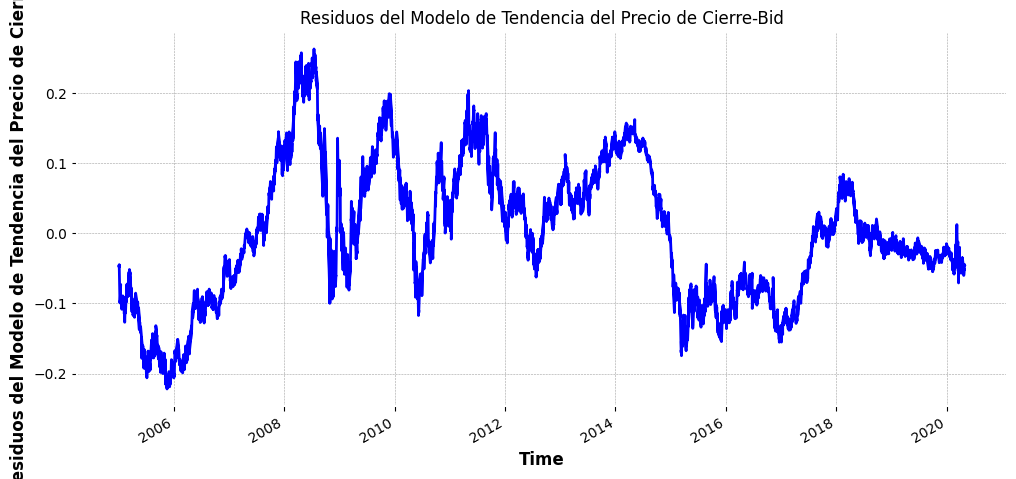

In [26]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5.5))
pd.Series(data=residuals, index=df_5m.index).plot(color='b')
plt.title('Residuos del Modelo de Tendencia del Precio de Cierre-Bid')
plt.xlabel('Time')
plt.ylabel('Residuos del Modelo de Tendencia del Precio de Cierre-Bid')
plt.xticks(rotation=30);

Para aislar la tendencia se ajusta un modelo (regresión lineal) y se extrae lo que este predice como dirección general del precio; los residuos corresponden a la diferencia entre el precio real y el estimado por dicha tendencia (Residuo = Precio real − Precio estimado), de modo que valores positivos indican que el precio estuvo por encima de la tendencia y negativos que estuvo por debajo. El análisis de estos residuos es útil por varias razones: en primer lugar, permite evaluar la calidad del modelo, ya que si los residuos son aleatorios y centrados en cero, la tendencia está bien capturada; en segundo lugar, facilita la identificación de desviaciones extremas, evidenciando momentos de sobrevaloración o subvaloración del euro; y en tercer lugar, permite observar procesos de reversión a la media, donde los desvíos tienden a corregirse en el tiempo. En particular, se observa un residuo positivo extremo en 2007–2008, asociado al auge previo a la crisis financiera, seguido de una reversión abrupta; entre 2010 y 2014 los residuos presentan alta dispersión, reflejando la inestabilidad de la crisis de deuda europea; y a partir de 2015 se comprimen alrededor de cero, lo que sugiere un régimen más estable influenciado por la divergencia de políticas monetarias entre la Fed y el BCE. Finalmente, el residuo cercano a cero en 2020 indica que, pese al shock del COVID-19, el tipo de cambio se mantuvo alineado con su tendencia de largo plazo, evidenciando que el impacto fue transitorio más que estructural.

### **2.5. Análisis de Estacionalidad**

####  **2.5.1. Gráfico de subserie estacional**

         Year Quarter  Quarterly Mean  Quarterly Standard Deviation
2005-Q1  2005      Q1       -0.090163                      0.009550
2005-Q2  2005      Q2       -0.138756                      0.038245
2005-Q3  2005      Q3       -0.171438                      0.013954
2005-Q4  2005      Q4       -0.198709                      0.011792
2006-Q1  2006      Q1       -0.180489                      0.008270


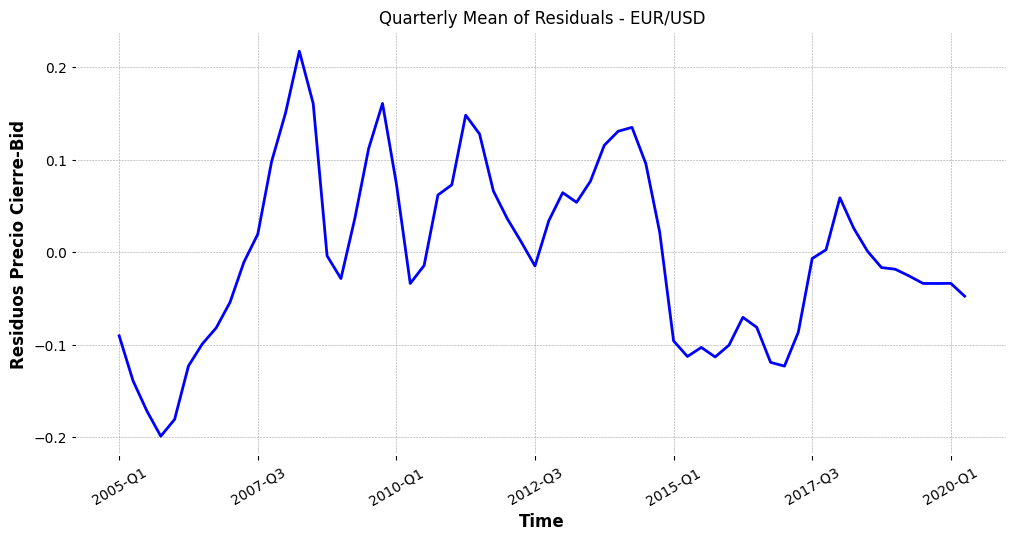

In [27]:
# 1. Resamplea residuos a mensual
residuals_series = pd.Series(data=residuals, index=df_5m.index)
residuals_monthly = residuals_series.resample('M').median()

# 2. Crea el DataFrame base
data = residuals_monthly.reset_index()
data.columns = ['Date', 'Residuals']
data['Year'] = data['Date'].dt.year
data['Month'] = data['Date'].dt.month

# 3. Mapea trimestres
month_quarter_map = {1: 'Q1', 2: 'Q1', 3: 'Q1',
                     4: 'Q2', 5: 'Q2', 6: 'Q2',
                     7: 'Q3', 8: 'Q3', 9: 'Q3',
                     10: 'Q4', 11: 'Q4', 12: 'Q4'}
data['Quarter'] = data['Month'].map(lambda m: month_quarter_map.get(m))

# 4. Calcula media y desviación estándar trimestral
seasonal_sub_series_data = data.groupby(by=['Year', 'Quarter'])['Residuals'].aggregate([np.mean, np.std])
seasonal_sub_series_data.columns = ['Quarterly Mean', 'Quarterly Standard Deviation']

# 5. Crea índice Year-Quarter
seasonal_sub_series_data.reset_index(inplace=True)
seasonal_sub_series_data.index = seasonal_sub_series_data['Year'].astype(str) + '-' + seasonal_sub_series_data['Quarter']

print(seasonal_sub_series_data.head())

# 6. Grafica
plt.figure(figsize=(12, 5.5))
seasonal_sub_series_data['Quarterly Mean'].plot(color='b')
plt.title('Quarterly Mean of Residuals - EUR/USD')
plt.xlabel('Time')
plt.ylabel('Residuos Precio Cierre-Bid')
plt.xticks(rotation=30)
plt.show()


Para identificar patrones estacionales en los residuos del EUR/USD, se tomó la serie de residuos calculada anteriormente y se redujo su granularidad de velas de 5 minutos a una observación por mes, usando la mediana mensual en lugar de la media para reducir el efecto de los valores extremos que caracterizan a este par en períodos de crisis. Luego cada mes se clasificó dentro de su trimestre correspondiente y se calculó la media de esos residuos por combinación año-trimestre, lo que genera exactamente la serie que muestra el gráfico: un punto por cada trimestre desde 2002-Q1 hasta 2020-Q1.
El objetivo de hacer este ejercicio es claro: si los residuos tuvieran comportamiento puramente aleatorio, la media trimestral oscilaría sin patrón alrededor de cero. Si en cambio aparecen ciclos reconocibles, eso indica que hay fuerzas estacionales o cíclicas que el modelo de tendencia no capturó y que se están manifestando en los residuos. Los residuos del EUR/USD no se comportan como ruido aleatorio, sino que muestran ciclos persistentes de mediano plazo, lo que indica la presencia de dinámicas cíclicas más allá de la tendencia lineal. Entre 2005 y 2006 se observan valores negativos profundos, reflejando un periodo de dólar fuerte, seguido por un aumento sostenido hasta 2008, donde se alcanza un máximo cercano a +0.22, evidenciando una sobrevaluación del euro previa a la crisis financiera. Entre 2008 y 2013 predominan oscilaciones cortas y volátiles, asociadas a la crisis de deuda europea, sin una dirección clara. Posteriormente, en 2014–2015 se presenta un ciclo negativo importante vinculado a la expansión cuantitativa (QE) implementada por el Banco Central Europeo (BCE), política mediante la cual se inyecta liquidez en la economía aumentando la oferta de euros y presionando su depreciación, seguido de una recuperación parcial en 2017. Finalmente, desde 2018 hasta 2020 los residuos se mantienen cercanos a cero y con menor amplitud, lo que sugiere un régimen más estable y con menor desviación respecto a la tendencia.

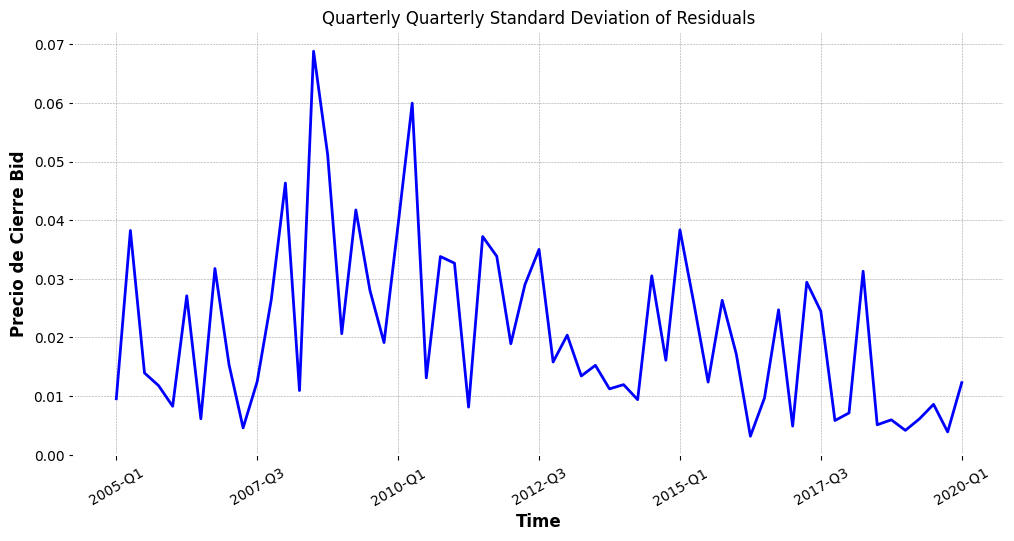

In [28]:
plt.figure(figsize=(12, 5.5))
seasonal_sub_series_data['Quarterly Standard Deviation'].plot(color='b')
plt.title('Quarterly Quarterly Standard Deviation of Residuals')
plt.xlabel('Time')
plt.ylabel('Precio de Cierre Bid')
plt.xticks(rotation=30);

La desviación estándar trimestral de los residuos captura la dispersión interna dentro de cada periodo, complementando a la media, que refleja la dirección respecto a la tendencia. A diferencia de la media, la volatilidad no sigue ciclos prolongados, sino que presenta picos puntuales, evidenciando que es un fenómeno más episódico que estructural. Los mayores niveles se observan en 2008 y 2010, asociados a la crisis financiera global y la crisis de deuda europea, donde el mercado mostró movimientos altamente inestables. A partir de 2012, la volatilidad entra en un régimen más bajo y estable, incluso en periodos de caída sostenida como 2014–2015, lo que indica movimientos más ordenados. El leve aumento en 2020 por el COVID-19 es relativamente moderado, sugiriendo mayor resiliencia del sistema financiero. En conjunto, la media y la desviación estándar muestran que el EUR/USD presenta ciclos de desviación respecto a su tendencia, pero con volatilidad concentrada principalmente en episodios de crisis.

#### **2.5.2. Gráficos de cajas múltiples**

Text(0, 0.5, 'Residuos Precio Cierre-Bid')

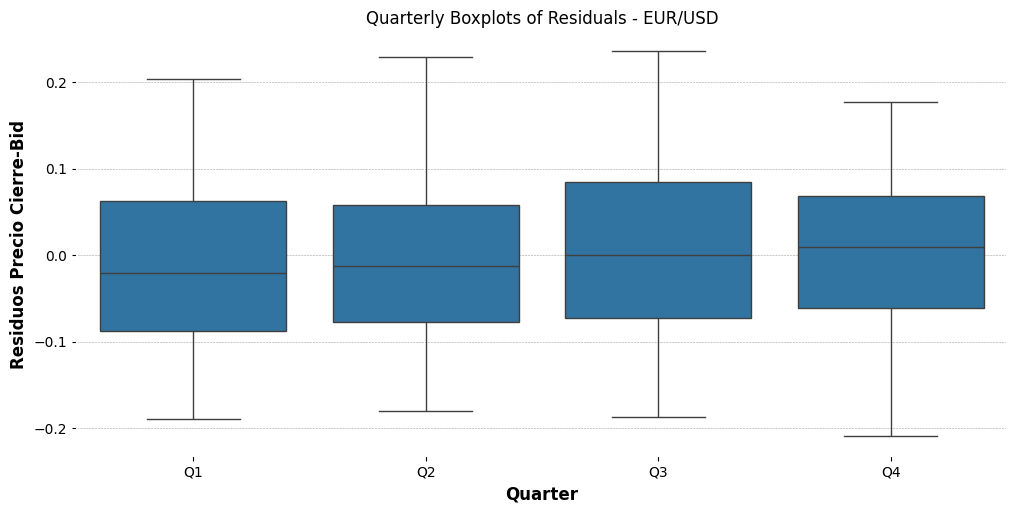

In [30]:
plt.figure(figsize=(12, 5.5))
g = sns.boxplot(data=data, y='Residuals', x='Quarter')
g.set_title('Quarterly Boxplots of Residuals - EUR/USD')
g.set_xlabel('Quarter')
g.set_ylabel('Residuos Precio Cierre-Bid')

Se construye un boxplot utilizando la librería seaborn con el fin de analizar la distribución de los residuos por trimestre, lo que permite comparar su dispersión, mediana y presencia de valores extremos. A partir de este gráfico se observa que los trimestres Q2 y Q3 presentan la mayor varianza. En particular, Q2 muestra el rango total más amplio, con un bigote superior que alcanza aproximadamente +0.22 y un bigote inferior cercano a -0.21, evidenciando fuertes desviaciones tanto positivas como negativas. Por su parte, Q3 exhibe una caja intercuartílica más ancha, lo que indica una mayor dispersión en los valores centrales, no solo en los extremos. En contraste, Q1 presenta una distribución más compacta, con una mediana ligeramente negativa, sugiriendo que los primeros trimestres tienden a concentrarse en valores por debajo de la tendencia. Finalmente, Q4 es el trimestre más simétrico, con una mediana cercana a cero y una dispersión moderada. En conjunto, el análisis muestra que la mayor variabilidad de los residuos se concentra en el segundo y tercer trimestre, mientras que el primero y el cuarto presentan un comportamiento más estable y cercano a la tendencia.

### **2.6. Comportamiento Cíclico**

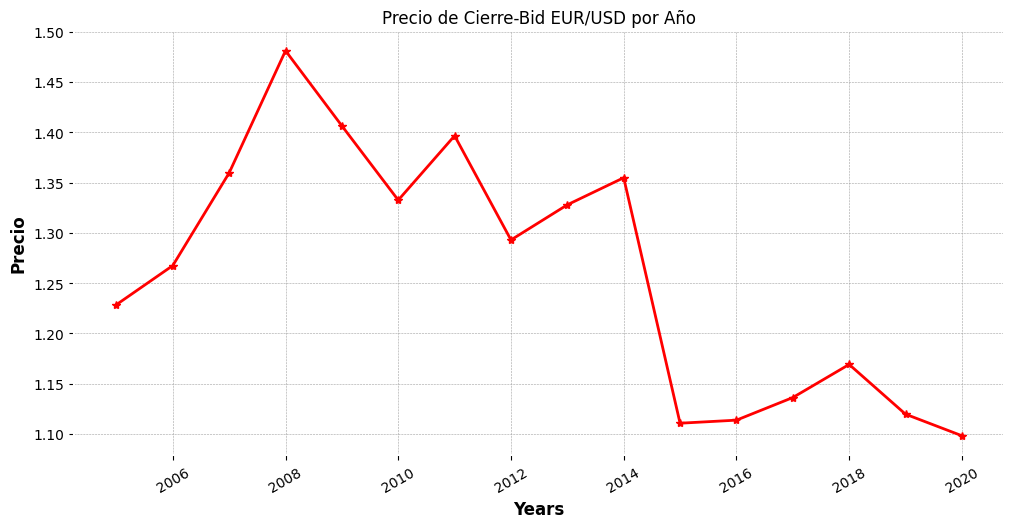

In [28]:
# Promedio anual del precio de cierre
annual = df_5m['BC'].resample('Y').median()

plt.figure(figsize=(12, 5.5))
plt.plot(annual.index.year, annual.values, linestyle='-', marker='*', color='r')
plt.title('Precio de Cierre-Bid EUR/USD por Año')
plt.ylabel('Precio')
plt.xlabel('Years')
plt.xticks(rotation=30)
plt.show()

Se remuestrea el precio de cierre Bid a frecuencia anual utilizando la mediana como medida de agregación, con el fin de reducir el impacto de valores extremos intradía y obtener una representación más robusta del nivel de precios. El análisis evidencia dos regímenes claramente diferenciados: entre 2002 y 2014 el EUR/USD se mantiene en una banda alta (1.23–1.48), con un pico en 2008 y una recuperación en 2011, reflejando la fortaleza del euro. A partir de 2015 se observa una ruptura estructural, con una caída abrupta desde 1.35 en 2014 a 1.11 en 2015, tras la cual el par no logra recuperar sus niveles previos. Aunque en 2018 se presenta un leve repunte, la tendencia descendente continúa hasta 2020, donde se alcanzan los niveles más bajos de la serie.

### **2.7. Modelos irregulares**

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

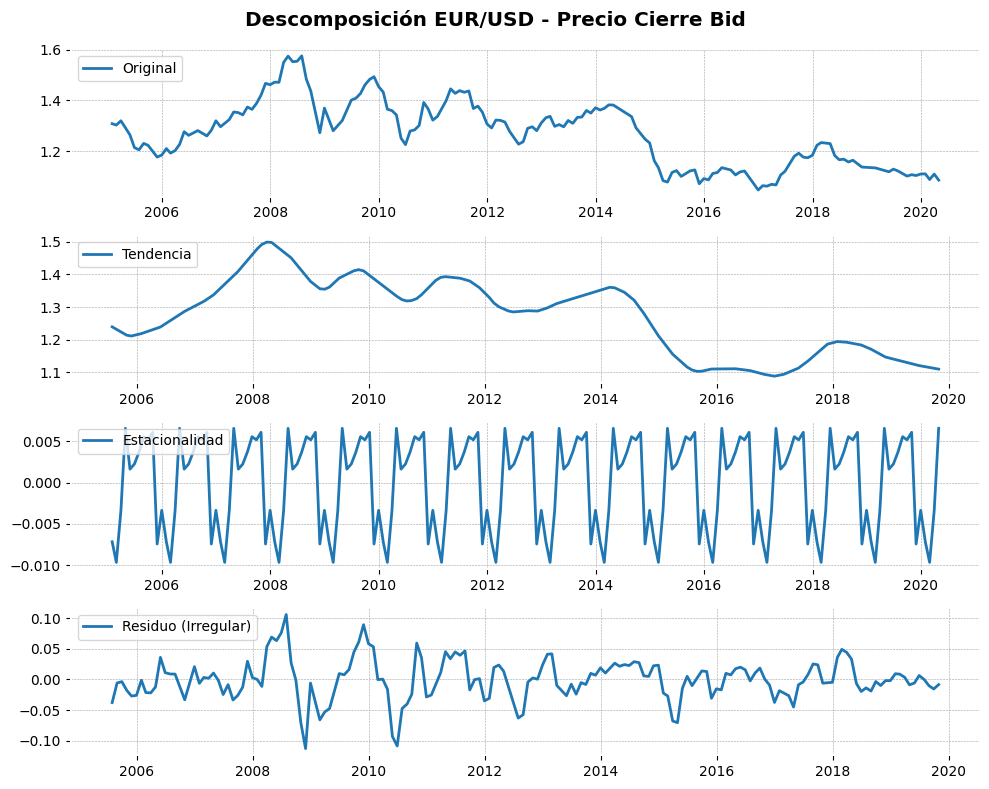

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Resamplea a mensual para que sea manejable
bc_monthly = df_5m['BC'].resample('M').median()

# Descomposición
decomposition = seasonal_decompose(bc_monthly, model='additive', period=12)

# Gráfica
plt.figure(figsize=(10, 8))
plt.subplot(411)
plt.plot(bc_monthly, label='Original')
plt.legend(loc='upper left')

plt.subplot(412)
plt.plot(decomposition.trend, label='Tendencia')
plt.legend(loc='upper left')

plt.subplot(413)
plt.plot(decomposition.seasonal, label='Estacionalidad')
plt.legend(loc='upper left')

plt.subplot(414)
plt.plot(decomposition.resid, label='Residuo (Irregular)')
plt.legend(loc='upper left')

plt.suptitle('Descomposición EUR/USD - Precio Cierre Bid')
plt.tight_layout()
plt.show()


Previamente, la serie fue remuestreada a frecuencia mensual con el fin de facilitar la identificación de patrones de largo plazo y permitir la aplicación de la descomposición. Se utiliza la librería statsmodels, específicamente seasonal_decompose, para realizar una descomposición aditiva, donde la serie se expresa como la suma de tendencia, estacionalidad y residuo (Serie = T + S + R). Este enfoque asume que la estacionalidad es constante en el tiempo. Se emplea un periodo de 12 para capturar patrones anuales en datos mensuales.

Serie original:
Muestra el EUR/USD entre 2002 y 2020, con un cambio de régimen: niveles altos hasta 2014 y valores más bajos desde 2015.

Tendencia:
Evidencia un quiebre estructural en 2014, pasando de una fase alcista hasta 2008 a una caída sostenida que se estabiliza cerca de 1.10. El rebote de 2018 no altera la tendencia.

Estacionalidad:
Presenta un patrón constante y repetitivo cada año, con baja amplitud, consistente con el modelo aditivo.

Residuo:
Captura shocks como la crisis de 2008–2010; posteriormente, se reduce y se mantiene cercano a cero, indicando mayor estabilidad en años recientes.

### **2.8. Modelos de análisis de series temporales**

### **2.9. Camino Aleatorio**

Text(0, 0.5, 'Suma acumulada Precio de cierre (5 minutos)')

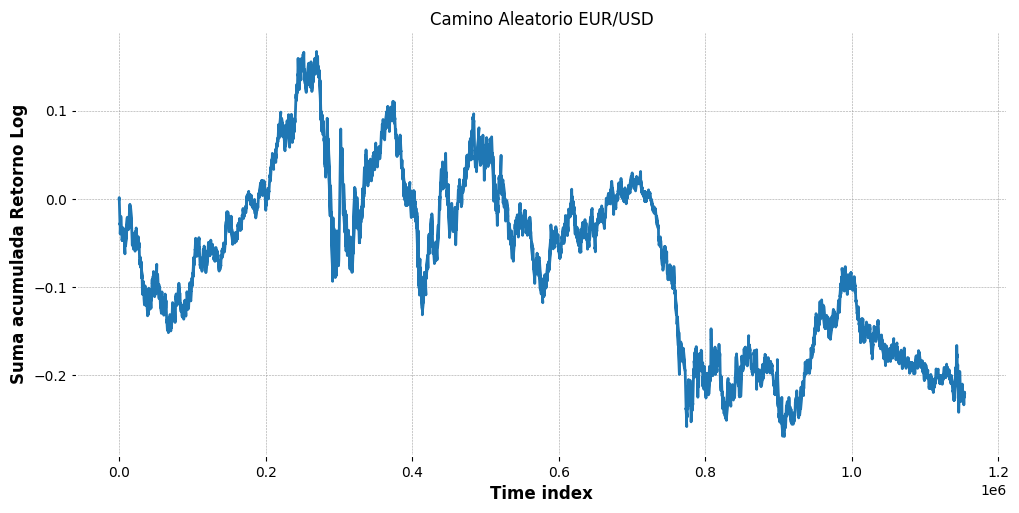

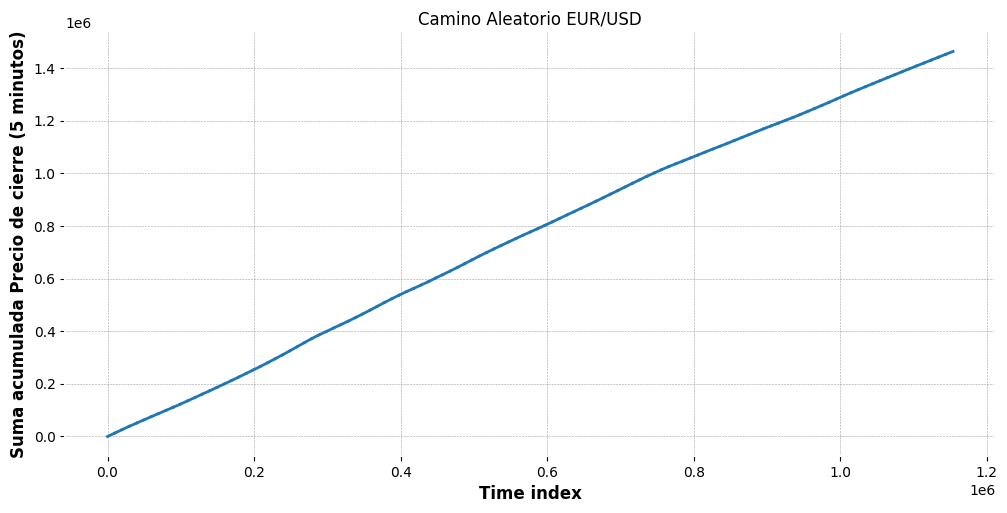

In [33]:
random_walk = np.cumsum(df_5m['Retorno_log'].dropna())

plt.figure(figsize=(12, 5.5))
g = sns.lineplot(data=random_walk.reset_index(drop=True))
g.set_title('Camino Aleatorio EUR/USD')
g.set_xlabel('Time index')
g.set_ylabel('Suma acumulada Retorno Log')

random_walk = np.cumsum(df_5m['BC'].dropna())

plt.figure(figsize=(12, 5.5))
g = sns.lineplot(data=random_walk.reset_index(drop=True))
g.set_title('Camino Aleatorio EUR/USD')
g.set_xlabel('Time index')
g.set_ylabel('Suma acumulada Precio de cierre (5 minutos)')

La suma acumulada de los retornos logarítmicos muestra ciclos con deriva persistente y direccional que no son compatibles con un proceso puramente aleatorio, ya que en un camino aleatorio verdadero esa serie debería oscilar de forma simétrica alrededor de cero sin tendencia sostenida en ninguna dirección. Por su parte, la suma acumulada del precio de cierre crece de forma casi perfectamente lineal a lo largo de toda la serie, lo que es la firma de una tendencia determinista de largo plazo y no el comportamiento irregular y divergente que produciría un camino aleatorio genuino. Ambos gráficos apuntan en la misma dirección: el EUR/USD en este período tiene memoria, sus retornos no son independientes entre sí y su precio responde a fuerzas estructurales de largo plazo, lo que descarta la hipótesis de camino aleatorio.

### **2.10. Modelos de tendencia**

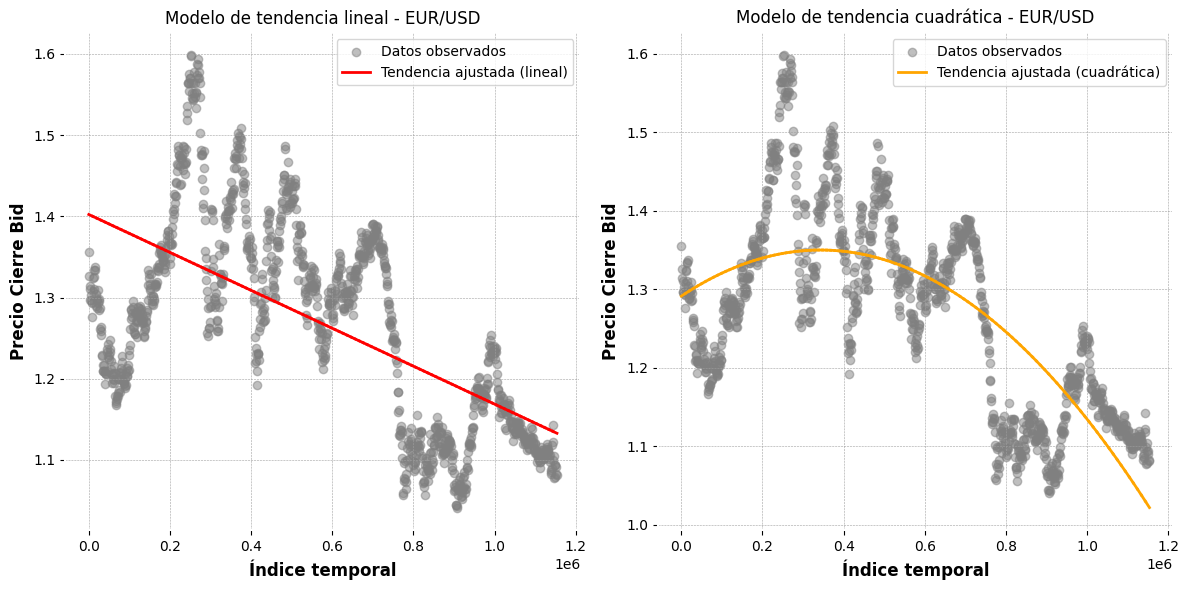

In [34]:
# Índice temporal
t = np.arange(df_5m.shape[0])

# Tendencia lineal ya calculada
fitted_trend_linear = trend_model.predict(t.reshape(-1, 1))

# Tendencia cuadrática con polyfit
coeffs_quadratic = np.polyfit(t, df_5m['BC'], 2)
fitted_trend_quadratic = np.polyval(coeffs_quadratic, t)

# Grafica
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.scatter(t[::1000], df_5m['BC'].values[::1000], color='gray', alpha=0.5, label='Datos observados')
plt.plot(t, fitted_trend_linear, color='red', label='Tendencia ajustada (lineal)')
plt.title('Modelo de tendencia lineal - EUR/USD')
plt.xlabel('Índice temporal')
plt.ylabel('Precio Cierre Bid')
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(t[::1000], df_5m['BC'].values[::1000], color='gray', alpha=0.5, label='Datos observados')
plt.plot(t, fitted_trend_quadratic, color='orange', label='Tendencia ajustada (cuadrática)')
plt.title('Modelo de tendencia cuadrática - EUR/USD')
plt.xlabel('Índice temporal')
plt.ylabel('Precio Cierre Bid')
plt.legend()

plt.tight_layout()
plt.show()

Se construye un índice temporal numérico simple que va desde cero hasta el total de observaciones, lo que permite tratar el tiempo como una variable continua para ajustar modelos de regresión. Con ese índice se ajustan dos modelos de tendencia sobre el precio de cierre Bid: uno lineal, que ya había sido calculado previamente con un modelo de regresión, y uno cuadrático, que se obtiene con polyfit de grado 2, es decir, una parábola que permite capturar no solo una pendiente constante sino también un punto de inflexión en la serie. Vale destacar que la visualización no usa la totalidad de los datos sino una muestra representativa, tomando uno de cada mil puntos para no saturar el scatter con el millón de observaciones disponibles, aunque los modelos de tendencia sí se ajustan sobre la serie completa.
Dicho esto, ninguno de los dos se ajusta bien a los datos. La línea roja lineal es demasiado rígida para una serie con ciclos tan pronunciados: subestima el precio en la primera mitad y lo sobreestima en la segunda, sin poder capturar ni el pico de 2008 ni la caída abrupta de 2014. La parábola naranja mejora visualmente al recoger el arco general de subida y bajada, pero exagera la caída al final de la serie proyectando una depreciación del euro mucho más severa de lo que realmente ocurrió, ignorando por completo la estabilización que tuvo el par en los últimos años del período. Ambos modelos son demasiado simples para una serie que atravesó cambios de régimen tan profundos como esta.

### **2.11. Autocorrelación y autocorrelación parcial**

<Figure size 1200x550 with 0 Axes>

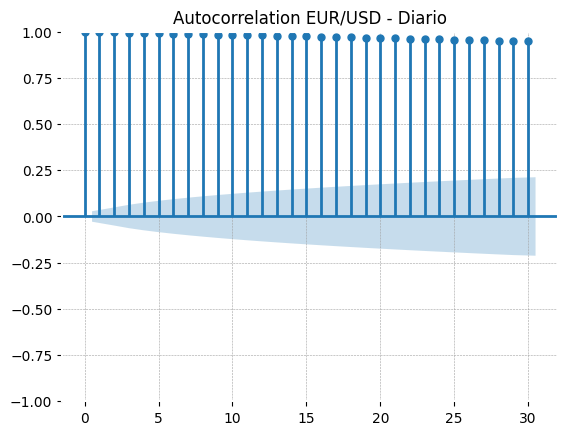

<Figure size 1200x550 with 0 Axes>

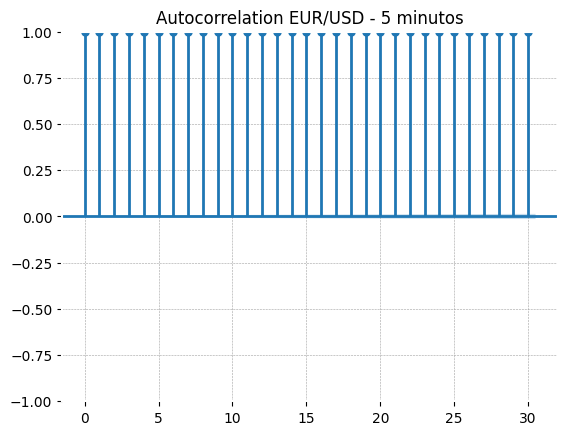

In [32]:
from statsmodels.graphics.tsaplots import plot_acf

# Diario
bc_daily = df_5m['BC'].resample('D').median().dropna()
plt.figure(figsize=(12, 5.5))
plot_acf(bc_daily, lags=30)
plt.title('Autocorrelation EUR/USD - Diario')
plt.show()

# 5 minutos
plt.figure(figsize=(12, 5.5))
plot_acf(df_5m['BC'], lags=30)
plt.title('Autocorrelation EUR/USD - 5 minutos')
plt.show()

La autocorrelación mide el grado en que una serie se parece a sí misma en el pasado. Dicho de otro modo, cuantifica si conocer el valor del precio hoy ayuda a predecir el valor de mañana o del siguiente período. Si la autocorrelación fuera cercana a cero en todos los rezagos, significaría que cada observación es independiente de las anteriores, lo que sería la firma de un camino aleatorio. El hecho de que ya descartáramos esa hipótesis en el análisis anterior hace que esperemos encontrar autocorrelaciones significativas y persistentes, es decir, que el precio de hoy guarde una relación fuerte con el de ayer, el de la semana pasada y el del mes anterior. Tanto en el gráfico diario como en el de 5 minutos, todas las barras de autocorrelación permanecen pegadas a un valor cercano a uno a lo largo de los 30 rezagos evaluados, muy por encima de las bandas de confianza que delimitan la zona donde una autocorrelación sería estadísticamente indistinguible de cero. Eso significa que el precio de cualquier período está altamente correlacionado con los períodos anteriores sin importar cuántos rezagos se retroceda dentro del rango analizado, lo que indica que la serie tiene memoria fuerte y persistente: el pasado reciente no solo importa sino que domina la formación del precio presente.

### **2.12. Autocorrelación Parcial**

<Figure size 1200x550 with 0 Axes>

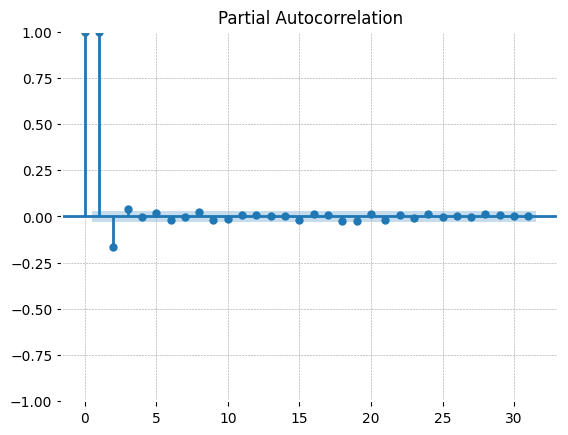

<Figure size 1200x550 with 0 Axes>

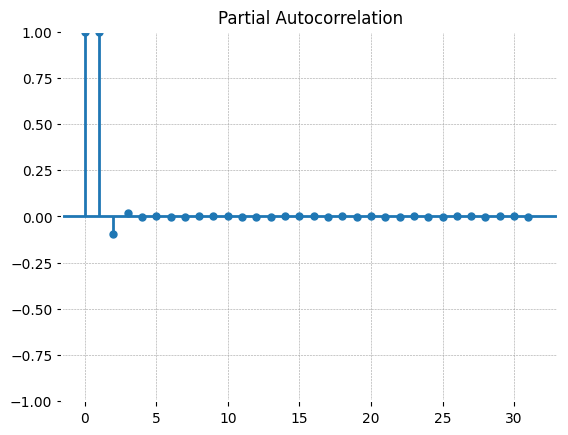

In [35]:
plt.figure(figsize=(12, 5.5));
plot_pacf(bc_daily, lags=31);


plt.figure(figsize=(12, 5.5));
plot_pacf(df_5m['BC'], lags=31);


Mientras que la autocorrelación parcial mide la correlación de la serie con un rezago específico descontando la influencia de los rezagos intermedios, por ejemplo la autocorrelación parcial en el rezago 2 captura la correlación entre el precio actual y el precio de hace dos períodos eliminando el efecto del período inmediatamente anterior, lo que permite ver si ese segundo rezago tiene una relación directa y propia con el presente o si su aparente influencia era simplemente un reflejo del primer rezago.
En los gráfico se puede observar como solo los dos primeros rezagos son significativos: el rezago uno con un valor cercano a uno y el rezago dos con un valor levemente negativo. A partir del rezago tres todas las barras caen dentro de las bandas de confianza y se mantienen en cero hasta el rezago 30. Esto indica que la única dependencia directa y genuina del precio está concentrada en las dos observaciones inmediatamente anteriores, y que todo lo que parecía memoria de largo plazo en la autocorrelación simple era simplemente el eco propagado de esa relación de primer y segundo orden.

### **2.13. Análisis de datos de series temporales**

### **2.13.1. Remuestreo de datos de series temporales**

In [38]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

Text(0, 0.5, 'Precio Cierre Bid')

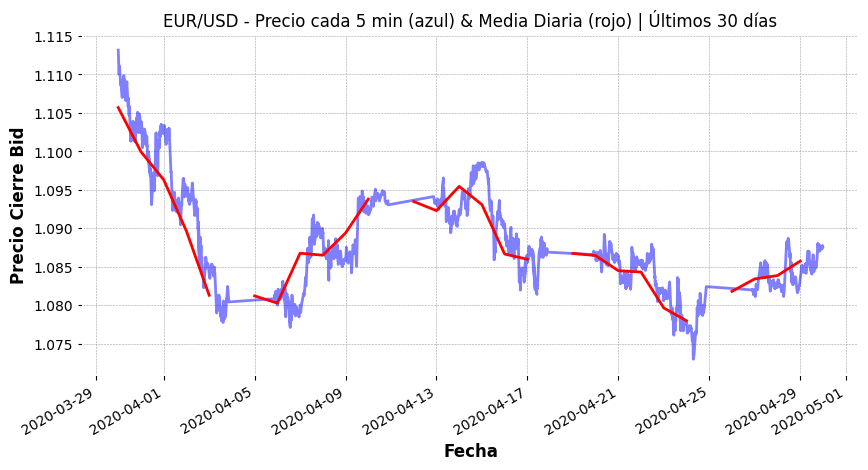

In [39]:
bc_5min_window = df_5m['BC']['2020-03-30':'2020-04-29']
bc_daily_window = df_5m['BC'].resample('D').mean()['2020-03-30':'2020-04-29']

fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(1,1,1)
bc_5min_window.plot(ax=ax, color='b', alpha=0.5)
bc_daily_window.plot(ax=ax, color='r', linewidth=2)
ax.set_title('EUR/USD - Precio cada 5 min (azul) & Media Diaria (rojo) | Últimos 30 días')
ax.set_xlabel('Fecha')
ax.set_ylabel('Precio Cierre Bid')

La técnica de remuestreo se ha aplicado en las secciones anteriores para realizar análisis de tendencia, ciclo y estacionalidad, además de usarlas para comparar el comportamiento de autocorrelación en un nivel de agregación mayor, para este gráfico se comparan los precios de EUR/USD en dos escalas: la serie de 5 minutos (azul) y la media diaria (rojo). Superponerlas permite ver simultáneamente el comportamiento intradía y la tendencia diaria. La línea roja actúa como filtro del ruido diario, mostrando únicamente la dirección sostenida al final de cada jornada. Este gráfico sirve para interpretar si los movimientos intradía tuvieron continuidad real o simplemente fueron absorbidos por el mercado sin reflejarse en el cierre diario.

                  BC Month_Year
Date                           
2005-01-02  1.355530    01-2005
2005-01-03  1.348946    01-2005
2005-01-04  1.337940    01-2005
2005-01-05  1.326501    01-2005
2005-01-06  1.320725    01-2005
   Month_Year      mean    median       std  Year Month
0     01-2005  1.312890  1.307208  0.014921  2005    01
16    02-2005  1.301424  1.302746  0.015242  2005    02
32    03-2005  1.319119  1.321176  0.018217  2005    03
48    04-2005  1.293964  1.292261  0.007341  2005    04
64    05-2005  1.268895  1.263558  0.015837  2005    05


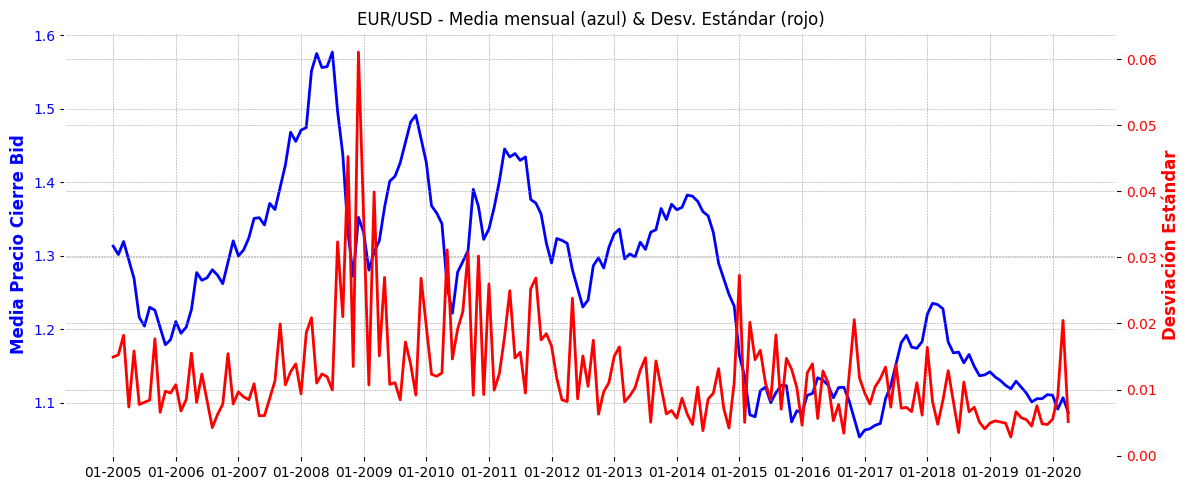

In [40]:
# Paso 1 - De 5 minutos a diario
df_daily = df_5m['BC'].resample('D').mean().reset_index()
df_daily.columns = ['Date', 'BC']
df_daily.set_index('Date', inplace=True)

# Paso 2 - Agregar columna Month_Year
df_daily['Month_Year'] = df_daily.index.map(lambda d: d.strftime('%m-%Y'))
print(df_daily.head())

# Paso 3 - Estadísticas mensuales
monthly_stats = df_daily.groupby(by='Month_Year')['BC'].aggregate([np.mean, np.median, np.std])
monthly_stats.reset_index(inplace=True)

# Paso 4 - Ordenar por año y mes
monthly_stats['Year'] = monthly_stats['Month_Year'].map(lambda m: pd.to_datetime(m, format='%m-%Y').strftime('%Y'))
monthly_stats['Month'] = monthly_stats['Month_Year'].map(lambda m: pd.to_datetime(m, format='%m-%Y').strftime('%m'))
monthly_stats.sort_values(by=['Year', 'Month'], inplace=True)

print(monthly_stats.head())

# Paso 5 - Grafica
monthly_stats.index = monthly_stats['Month_Year']


fig, ax1 = plt.subplots(figsize=(12, 5))

# Media en eje izquierdo
ax1.plot(monthly_stats['mean'].values, color='b', label='Media')
ax1.set_ylabel('Media Precio Cierre Bid', color='b')
ax1.tick_params(axis='y', labelcolor='b')

# Std en eje derecho
ax2 = ax1.twinx()
ax2.plot(monthly_stats['std'].values, color='r', label='Std')
ax2.set_ylabel('Desviación Estándar', color='r')
ax2.tick_params(axis='y', labelcolor='r')

plt.title('EUR/USD - Media mensual (azul) & Desv. Estándar (rojo)')
plt.xticks(range(0, len(monthly_stats), 12), monthly_stats['Month_Year'].values[::12], rotation=45)
plt.tight_layout()
plt.show()

Se comparan la media y la desviación estándar mensual de los precios de EUR/USD para ver no solo el nivel del precio sino también su dispersión, que refleja la actividad y la incertidumbre del mercado en cada mes. El gráfico muestra que el pico de volatilidad coincide con el máximo histórico de la media alrededor de 2008-2009, indicando que el rally del euro antes del colapso de Lehman fue un período de fuertes subidas acompañadas de movimientos intradía violentos. Desde 2015 en adelante, la media se estabiliza en niveles bajos y la desviación estándar también se comprime, señalando un mercado depreciado pero predecible y sin grandes oscilaciones internas. El ligero repunte de volatilidad en los primeros meses de 2020 refleja el impacto del COVID, aunque mucho menor que la crisis financiera anterior, lo que indica que el sistema absorbió este shock con mayor eficiencia.

### **2.13.2. Estadísticos móviles**

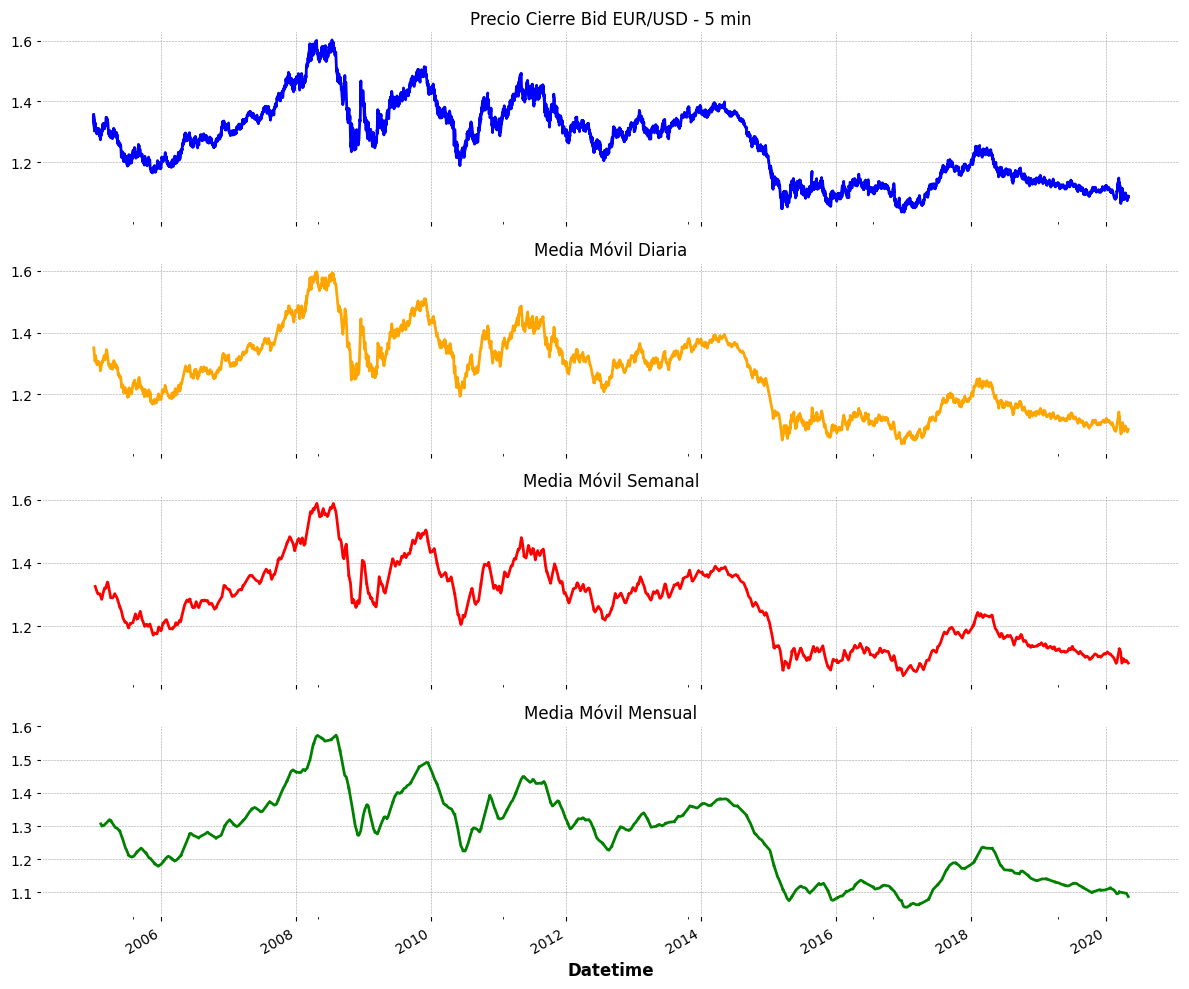

In [47]:
# Medias móviles
daily_moving_average = df_5m['BC'].rolling(24*12).mean()      # 1 día en periodos de 5 min
weekly_moving_average = df_5m['BC'].rolling(7*24*12).mean()   # 7 días en periodos de 5 min
monthly_moving_average = df_5m['BC'].rolling(30*24*12).mean() # 30 días en periodos de 5 min

fig, axarr = plt.subplots(4, sharex=True)
fig.set_size_inches(12, 10)

df_5m['BC'].plot(ax=axarr[0], color='b')
axarr[0].set_title('Precio Cierre Bid EUR/USD - 5 min')

daily_moving_average.plot(ax=axarr[1], color='orange')
axarr[1].set_title('Media Móvil Diaria')

weekly_moving_average.plot(ax=axarr[2], color='r')
axarr[2].set_title('Media Móvil Semanal')

monthly_moving_average.plot(ax=axarr[3], color='g')
axarr[3].set_title('Media Móvil Mensual')

plt.tight_layout()
plt.show()

### **2.14. Procesos estacionarios**


#### **2.14.1. Transformación de datos y ajustes (Diferenciación)**

In [48]:
from random import seed
from pandas import Series
import random 
from pandas.plotting import autocorrelation_plot
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa import stattools
from pandas.plotting import autocorrelation_plot

In [49]:
first_order_diff = df_5m['BC'].diff(1)
first_order_diff

Datetime
2005-01-02 18:25:00         NaN
2005-01-02 18:35:00    0.000000
2005-01-02 18:50:00    0.000600
2005-01-02 18:55:00    0.000150
2005-01-02 19:00:00    0.000150
                         ...   
2020-04-29 23:35:00    0.000145
2020-04-29 23:40:00    0.000030
2020-04-29 23:45:00    0.000010
2020-04-29 23:50:00   -0.000030
2020-04-29 23:55:00   -0.000120
Name: BC, Length: 1153890, dtype: float64

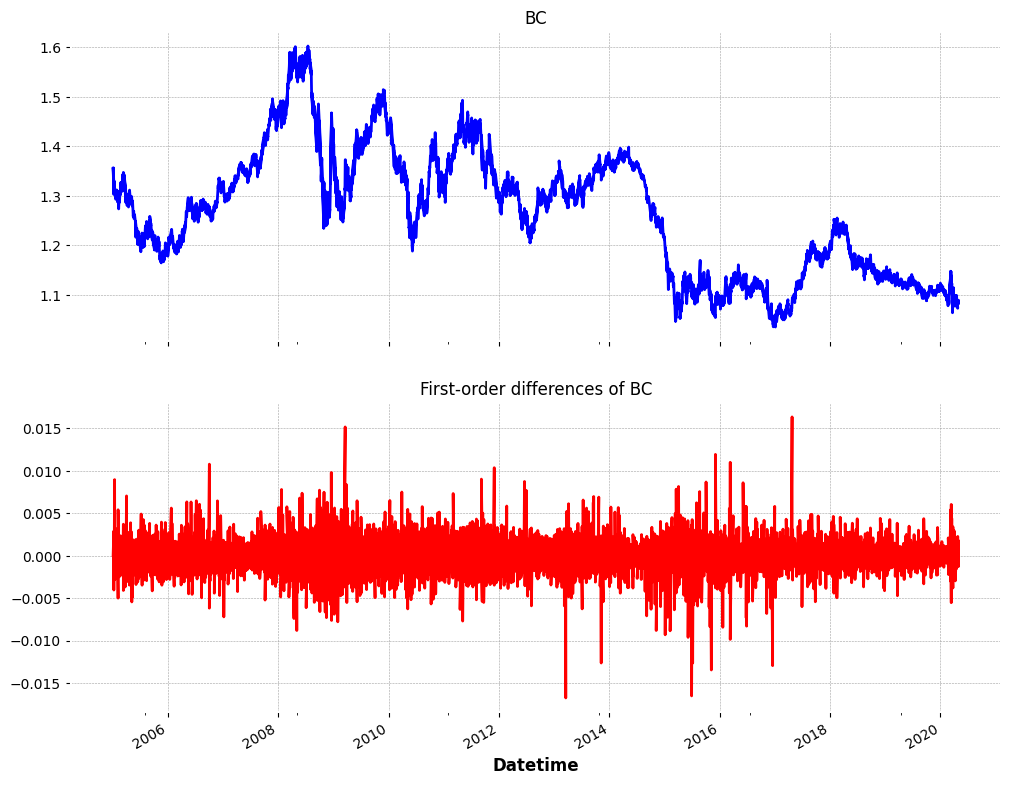

In [50]:
fig, ax = plt.subplots(2, sharex=True)
fig.set_size_inches(12, 10)
df_5m['BC'].plot(ax=ax[0], color='b');
ax[0].set_title('BC');
first_order_diff.plot(ax=ax[1], color='r');
ax[1].set_title('First-order differences of BC');

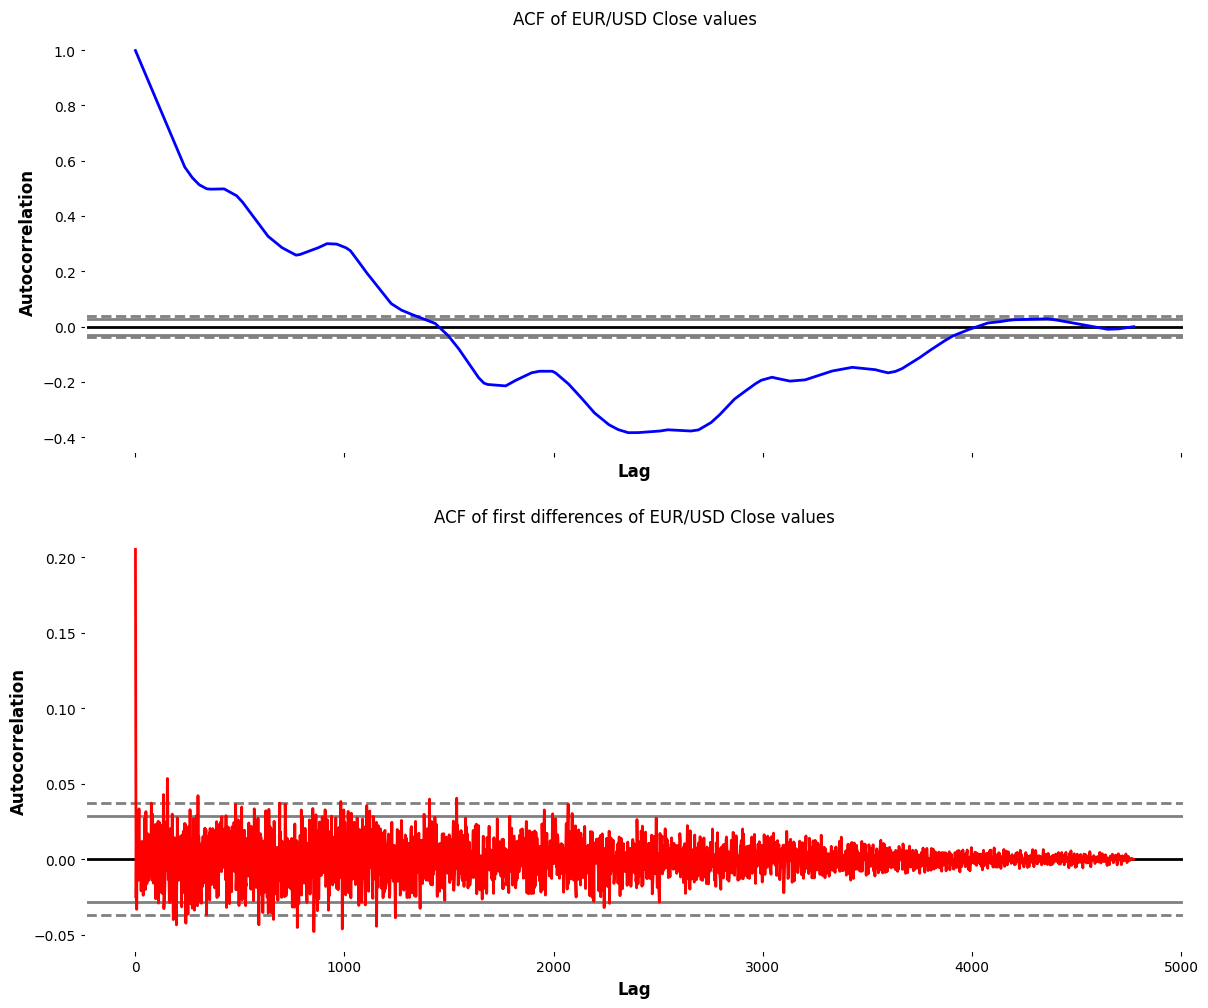

In [51]:
from pandas.plotting import autocorrelation_plot

bc_daily = df_5m['BC'].resample('D').median().dropna()
first_order_diff = bc_daily.diff().dropna()

fig, ax = plt.subplots(2, sharex=True)
fig.set_size_inches(12, 10)
autocorrelation_plot(bc_daily, color='b', ax=ax[0])
ax[0].set_title('ACF of EUR/USD Close values')
autocorrelation_plot(first_order_diff.iloc[1:], color='r', ax=ax[1])
ax[1].set_title('ACF of first differences of EUR/USD Close values')
plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=2.0)
plt.show()

In [52]:
acf_BC, confint_BC, qstat_BC, pvalues_BC = stattools.acf(df_5m['BC'],
                                                                 nlags=20,
                                                                 qstat=True,
                                                                 alpha=0.05)



In [53]:
alpha = 0.05
for l, p_val in enumerate(pvalues_BC):
    if p_val > alpha:
        print('Null hypothesis is accepted at lag = {} for p-val = {}'.format(l, p_val))
    else:
        print('Null hypothesis is rejected at lag = {} for p-val = {}'.format(l, p_val))

Null hypothesis is rejected at lag = 0 for p-val = 0.0
Null hypothesis is rejected at lag = 1 for p-val = 0.0
Null hypothesis is rejected at lag = 2 for p-val = 0.0
Null hypothesis is rejected at lag = 3 for p-val = 0.0
Null hypothesis is rejected at lag = 4 for p-val = 0.0
Null hypothesis is rejected at lag = 5 for p-val = 0.0
Null hypothesis is rejected at lag = 6 for p-val = 0.0
Null hypothesis is rejected at lag = 7 for p-val = 0.0
Null hypothesis is rejected at lag = 8 for p-val = 0.0
Null hypothesis is rejected at lag = 9 for p-val = 0.0
Null hypothesis is rejected at lag = 10 for p-val = 0.0
Null hypothesis is rejected at lag = 11 for p-val = 0.0
Null hypothesis is rejected at lag = 12 for p-val = 0.0
Null hypothesis is rejected at lag = 13 for p-val = 0.0
Null hypothesis is rejected at lag = 14 for p-val = 0.0
Null hypothesis is rejected at lag = 15 for p-val = 0.0
Null hypothesis is rejected at lag = 16 for p-val = 0.0
Null hypothesis is rejected at lag = 17 for p-val = 0.0
Nu

In [54]:
acf_first_diff, confint_first_diff,\
qstat_first_diff, pvalues_first_diff = stattools.acf(first_order_diff.iloc[1:],
                                                     nlags=20,
                                                     qstat=True,
                                                     alpha=0.05)

In [55]:
alpha = 0.05
for l, p_val in enumerate(pvalues_first_diff):
    if p_val > alpha:
        print('Null hypothesis is accepted at lag = {} for p-val = {}'.format(l, p_val))
    else:
        print('Null hypothesis is rejected at lag = {} for p-val = {}'.format(l, p_val))

Null hypothesis is rejected at lag = 0 for p-val = 1.2272822948081776e-45
Null hypothesis is rejected at lag = 1 for p-val = 1.568828974253562e-44
Null hypothesis is rejected at lag = 2 for p-val = 1.7686297922617214e-43
Null hypothesis is rejected at lag = 3 for p-val = 3.3068872748673155e-43
Null hypothesis is rejected at lag = 4 for p-val = 1.6412028195765364e-42
Null hypothesis is rejected at lag = 5 for p-val = 4.3175352336063026e-42
Null hypothesis is rejected at lag = 6 for p-val = 2.033537024347313e-42
Null hypothesis is rejected at lag = 7 for p-val = 9.778278312981476e-42
Null hypothesis is rejected at lag = 8 for p-val = 1.407041510332198e-41
Null hypothesis is rejected at lag = 9 for p-val = 5.429461874674374e-41
Null hypothesis is rejected at lag = 10 for p-val = 2.373243304169236e-40
Null hypothesis is rejected at lag = 11 for p-val = 1.033925571044662e-39
Null hypothesis is rejected at lag = 12 for p-val = 4.509629219379712e-39
Null hypothesis is rejected at lag = 13 for

Podemos ver su comportamiento estacional y aplicar las pruebas de ACF y ACF parcial

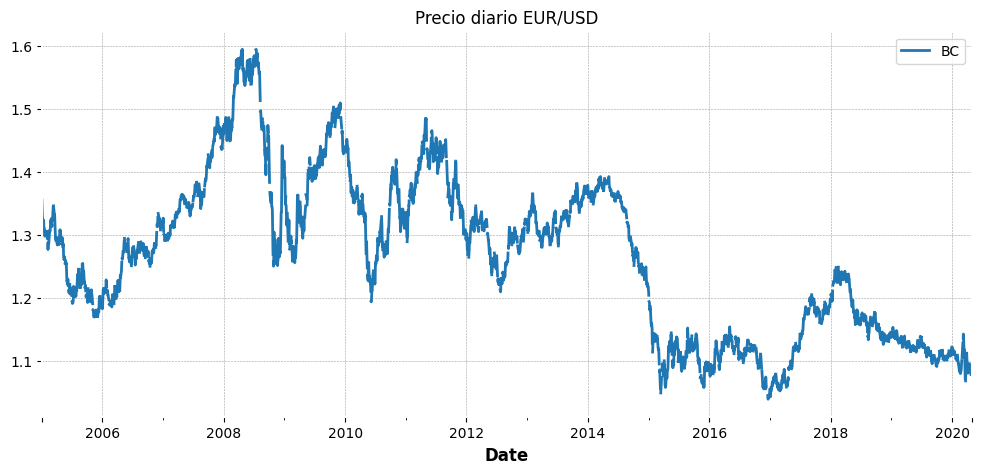

In [56]:
fig = plt.figure(figsize=(12, 5))
ax = fig.add_subplot(1,1,1)
ax.set_title('Precio diario EUR/USD')
df_daily.plot(ax=ax)
plt.show()

Shape of monthly mean EUR/USD dataset: (184,)
Datetime
2005-01-31    1.312525
2005-02-28    1.301520
2005-03-31    1.318475
2005-04-30    1.293962
2005-05-31    1.269107
Freq: ME, Name: BC, dtype: float64


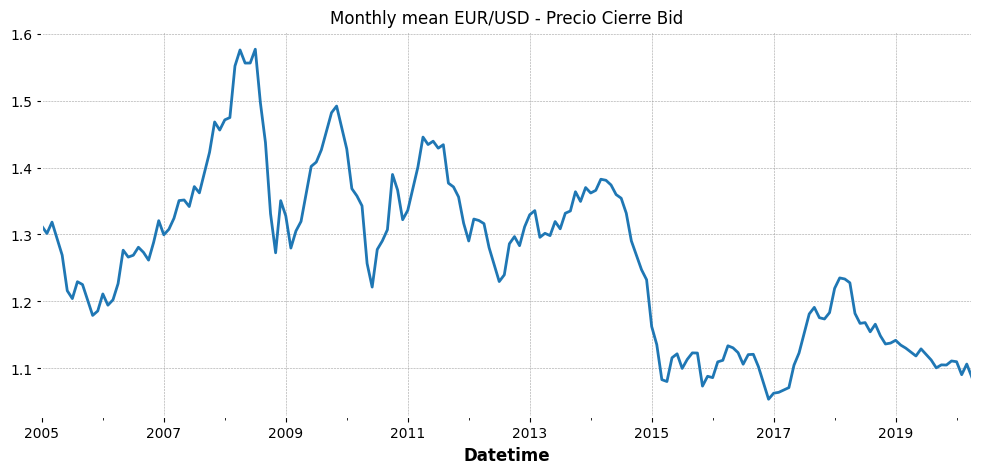

In [57]:
monthly_resample = df_5m['BC'].resample('M')
monthly_mean_bc = monthly_resample.mean()

print('Shape of monthly mean EUR/USD dataset:', monthly_mean_bc.shape)
print(monthly_mean_bc.head())

fig = plt.figure(figsize=(12, 5))
ax = fig.add_subplot(1,1,1)
ax.set_title('Monthly mean EUR/USD - Precio Cierre Bid')
monthly_mean_bc.plot(ax=ax)
plt.show()

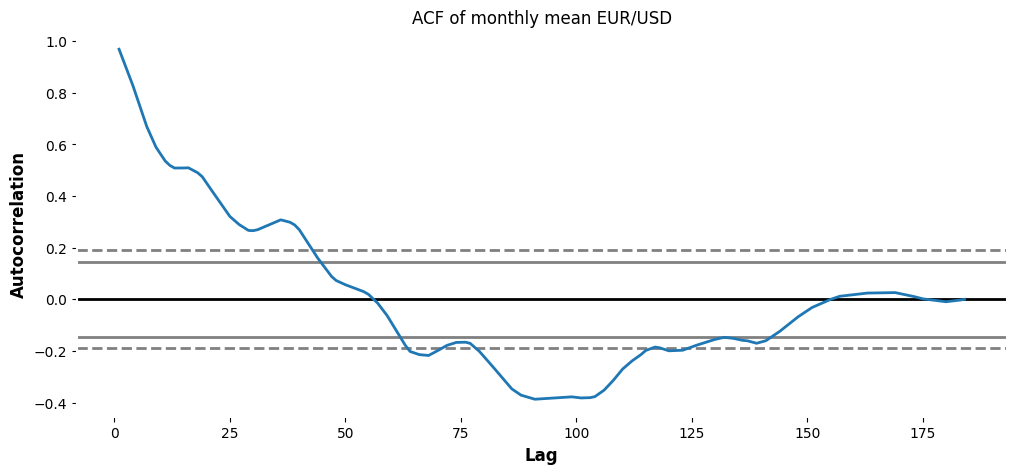

In [58]:
fig = plt.figure(figsize=(12, 5))
ax = fig.add_subplot(1,1,1)
ax.set_title('ACF of monthly mean EUR/USD')
autocorrelation_plot(monthly_mean_bc, ax=ax)
plt.show()

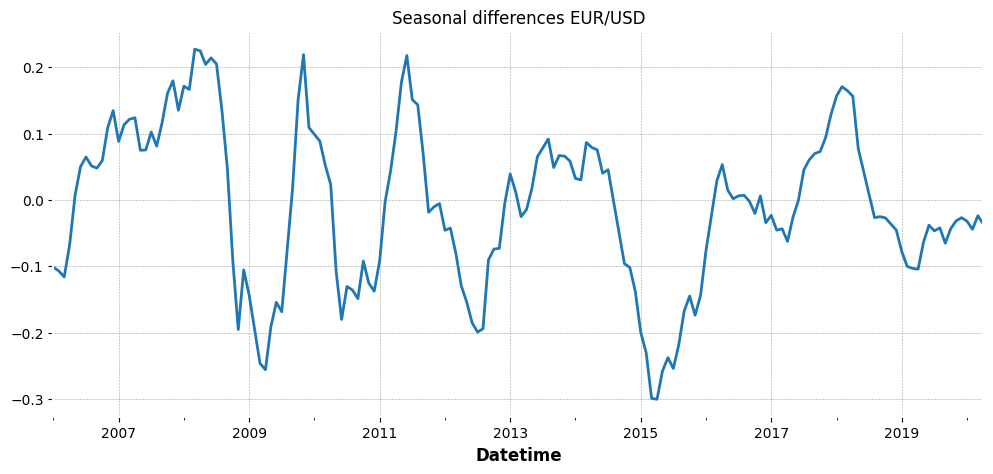

In [59]:
seasonal_diff = monthly_mean_bc.diff(12)
seasonal_diff = seasonal_diff[12:]

fig = plt.figure(figsize=(12, 5))
ax = fig.add_subplot(1,1,1)
ax.set_title('Seasonal differences EUR/USD')
seasonal_diff.plot(ax=ax)
plt.show()

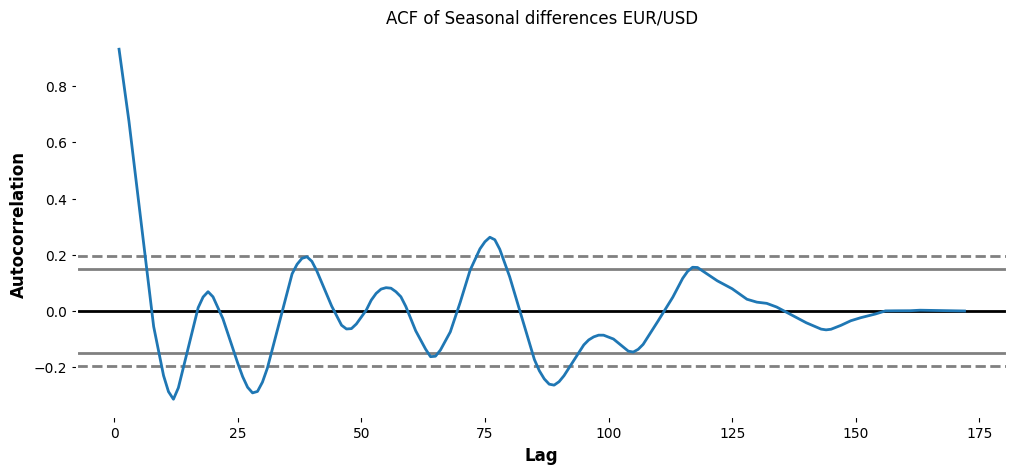

In [60]:
fig = plt.figure(figsize=(12, 5))
ax = fig.add_subplot(1,1,1)
ax.set_title('ACF of Seasonal differences EUR/USD')
autocorrelation_plot(seasonal_diff, ax=ax)
plt.show()

In [62]:
from statsmodels.tsa import stattools

# Ljung-Box sobre media mensual
_, _, _, pval_monthly_mean = stattools.acf(monthly_mean_bc, nlags=10, qstat=True, alpha=0.05)
print('Null hypothesis is rejected for lags:', np.where(pval_monthly_mean <= 0.05))

# Ljung-Box sobre diferencias estacionales
_, _, _, pval_seasonal_diff = stattools.acf(seasonal_diff, nlags=10, qstat=True, alpha=0.05)
print('Null hypothesis is rejected for lags:', np.where(pval_seasonal_diff <= 0.05))

Null hypothesis is rejected for lags: (array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=int64),)
Null hypothesis is rejected for lags: (array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=int64),)


#### **2.14.2. Prueba de Dickey-Fuller**

In [63]:
adf_result = stattools.adfuller(df_5m['BC'], autolag='AIC')
print('p-val of the ADF test in EUR/USD monthly mean:', adf_result[1])

p-val of the ADF test in EUR/USD monthly mean: 0.4329592567477676


### **2.15. Descomposición de series temporales**

#### **2.15.1. Medias móviles y efectos de suavización**


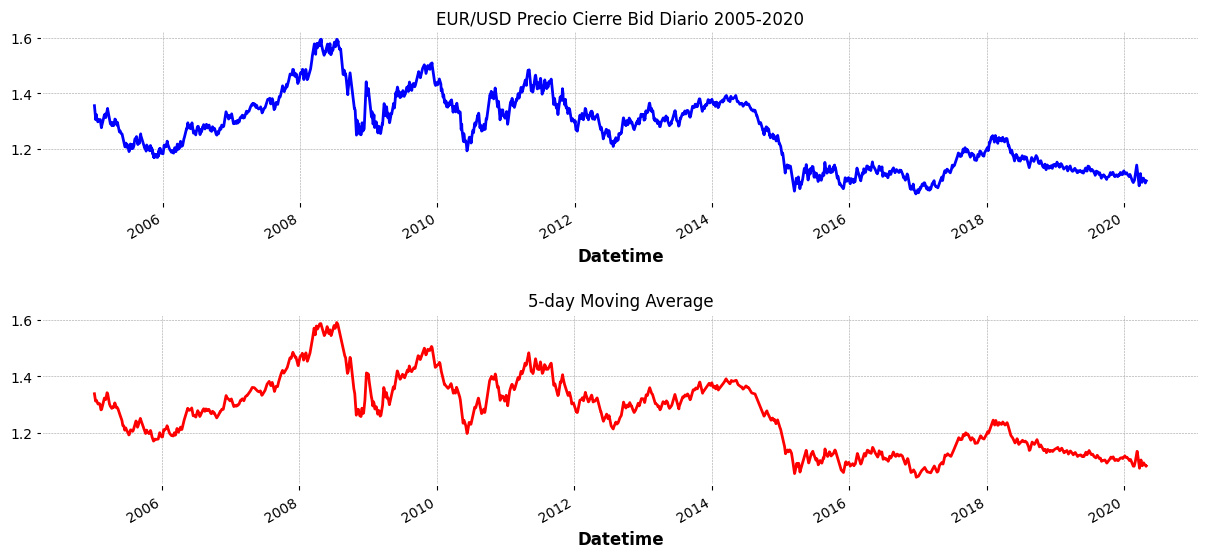

In [64]:
# Resamplear a diario
bc_daily_ma = df_5m['BC'].resample('D').mean().dropna()

# Media móvil de 5 días
bc_daily_ma_5 = bc_daily_ma.rolling(5).mean()

# Grafica
fig = plt.figure(figsize=(12, 5.5))
ax = fig.add_subplot(2,1,1)
bc_daily_ma.plot(ax=ax, color='b')
ax.set_title('EUR/USD Precio Cierre Bid Diario 2005-2020')

ax = fig.add_subplot(2,1,2)
bc_daily_ma_5.plot(ax=ax, color='r')
ax.set_title('5-day Moving Average')

plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=2.0)
plt.show()

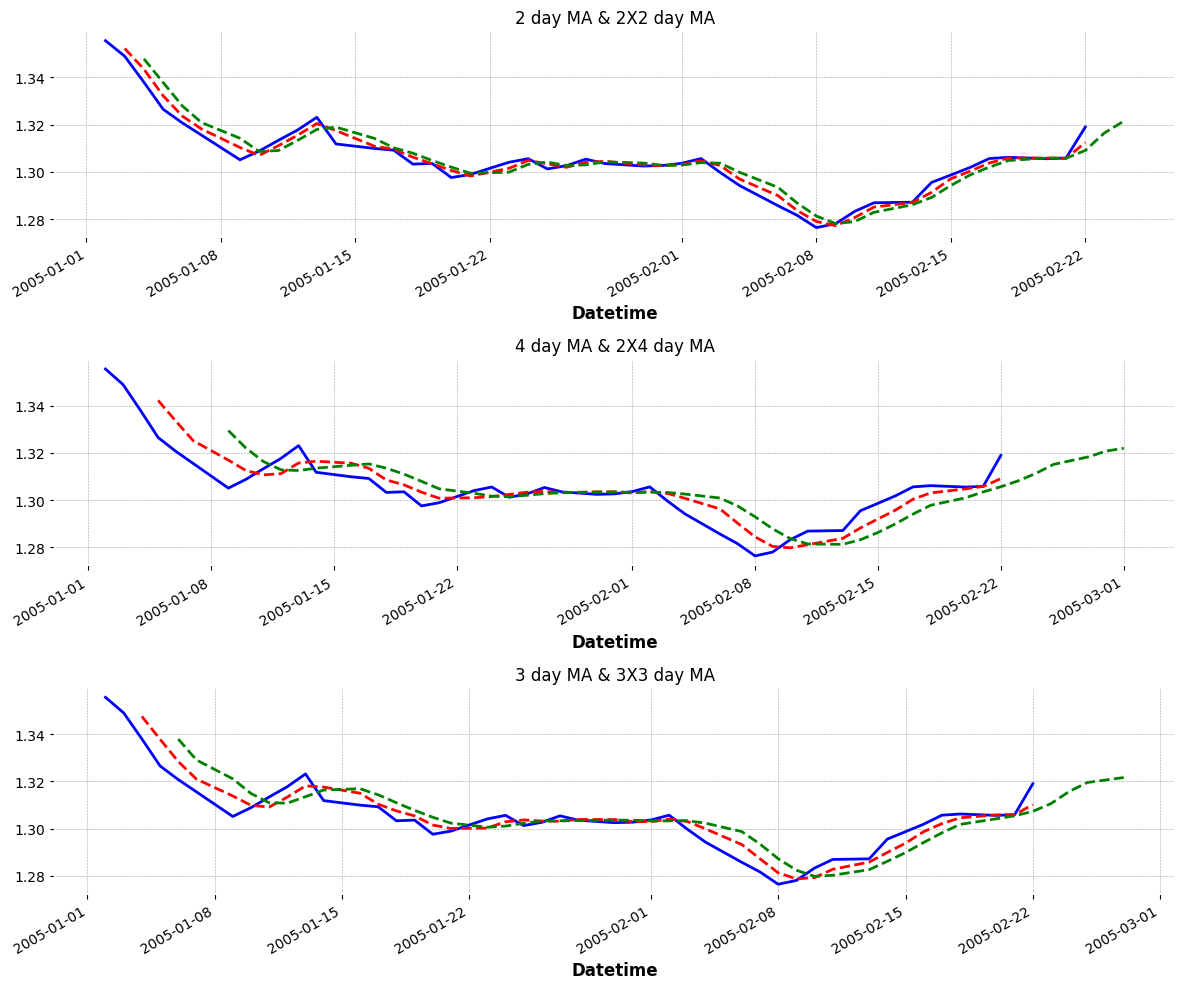

In [65]:
# Medias móviles
MA2 = bc_daily_ma.rolling(window=2).mean()
TwoXMA2 = MA2.rolling(window=2).mean()

MA4 = bc_daily_ma.rolling(window=4).mean()
TwoXMA4 = MA4.rolling(window=4).mean()

MA3 = bc_daily_ma.rolling(window=3).mean()
ThreeXMA3 = MA3.rolling(window=3).mean()

# Eliminar NaN
TwoXMA2 = TwoXMA2.dropna()
TwoXMA4 = TwoXMA4.dropna()
ThreeXMA3 = ThreeXMA3.dropna()

# Grafica
f, axarr = plt.subplots(3, sharex=False)
f.set_size_inches(12, 10)

bc_daily_ma.iloc[:45].plot(color='b', linestyle='-', ax=axarr[0])
MA2.iloc[:45].plot(color='r', linestyle='--', ax=axarr[0])
TwoXMA2.iloc[:45].plot(color='g', linestyle='--', ax=axarr[0])
axarr[0].set_title('2 day MA & 2X2 day MA')

bc_daily_ma.iloc[:45].plot(color='b', linestyle='-', ax=axarr[1])
MA4.iloc[:45].plot(color='r', linestyle='--', ax=axarr[1])
TwoXMA4.iloc[:45].plot(color='g', linestyle='--', ax=axarr[1])
axarr[1].set_title('4 day MA & 2X4 day MA')

bc_daily_ma.iloc[:45].plot(color='b', linestyle='-', ax=axarr[2])
MA3.iloc[:45].plot(color='r', linestyle='--', ax=axarr[2])
ThreeXMA3.iloc[:45].plot(color='g', linestyle='--', ax=axarr[2])
axarr[2].set_title('3 day MA & 3X3 day MA')

plt.tight_layout()
plt.show()

#### **2.15.2. Ajuste estacional mediante media móvil**

El EUR/USD muestra una serie temporal no estacionaria con memoria persistente, confirmada por la prueba ADF (p-val = 0.43) y la autocorrelación significativa en todos los rezagos analizados. La serie presenta una tendencia no lineal clara: una fase alcista entre 2005 y 2008 que llevó el par hasta niveles de 1.60, seguida de una caída abrupta durante la crisis financiera de 2008-2009, una recuperación parcial hasta 2011, y una tendencia bajista sostenida desde 2014 que estabilizó el precio alrededor de 1.10. La descomposición mensual revela que la variabilidad del precio es baja y relativamente constante a lo largo del tiempo, con una desviación estándar mensual que no supera 0.05, lo que indica que aunque el nivel del precio cambia estructuralmente, la volatilidad intrínseca de la serie es estable.

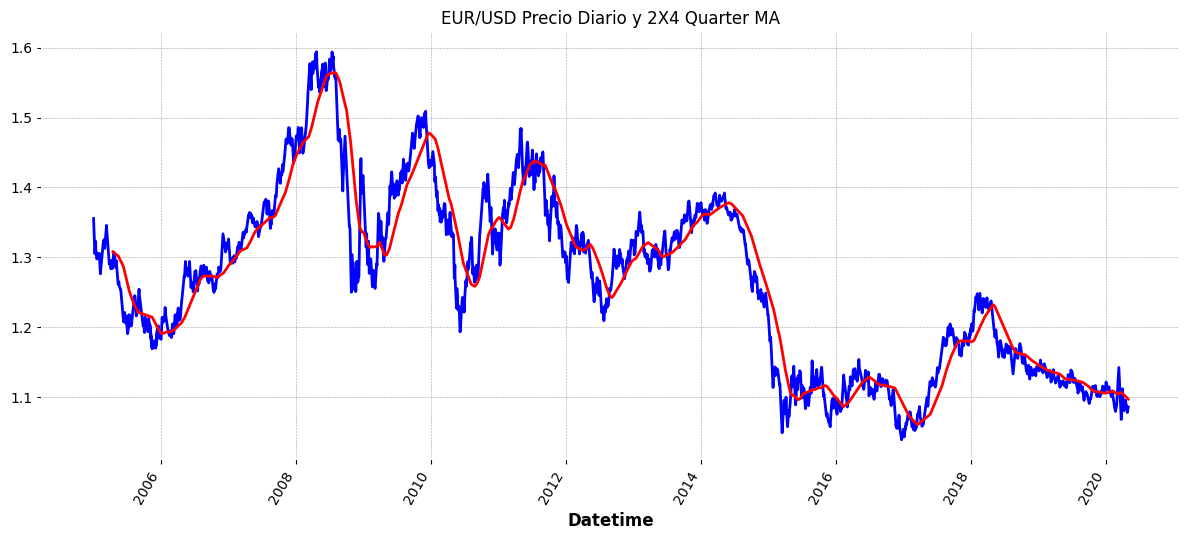

In [66]:
MA4 = bc_daily_ma.rolling(window=90).mean()
TwoXMA4 = MA4.rolling(window=2).mean()
TwoXMA4 = TwoXMA4.loc[~pd.isnull(TwoXMA4)]

fig = plt.figure(figsize=(12, 5.5))
ax = fig.add_subplot(1,1,1)
bc_daily_ma.plot(ax=ax, color='b', linestyle='-')
TwoXMA4.plot(ax=ax, color='r', linestyle='-')
plt.xticks(rotation=60)
ax.set_title('EUR/USD Precio Diario y 2X4 Quarter MA')
plt.tight_layout()
plt.show()

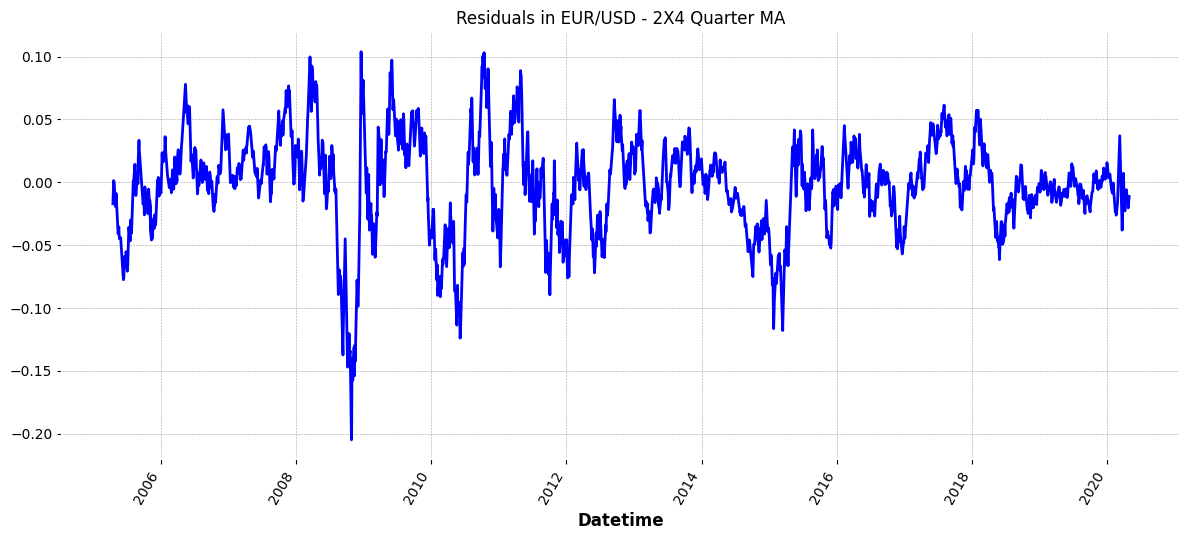

In [67]:
# Residuos sobre media móvil trimestral
residuals = bc_daily_ma - TwoXMA4
residuals = residuals.loc[~pd.isnull(residuals)]

fig = plt.figure(figsize=(12, 5.5))
ax = fig.add_subplot(1,1,1)
residuals.plot(ax=ax, color='b', linestyle='-')
plt.xticks(rotation=60)
ax.set_title('Residuals in EUR/USD - 2X4 Quarter MA')
plt.tight_layout()
plt.show()

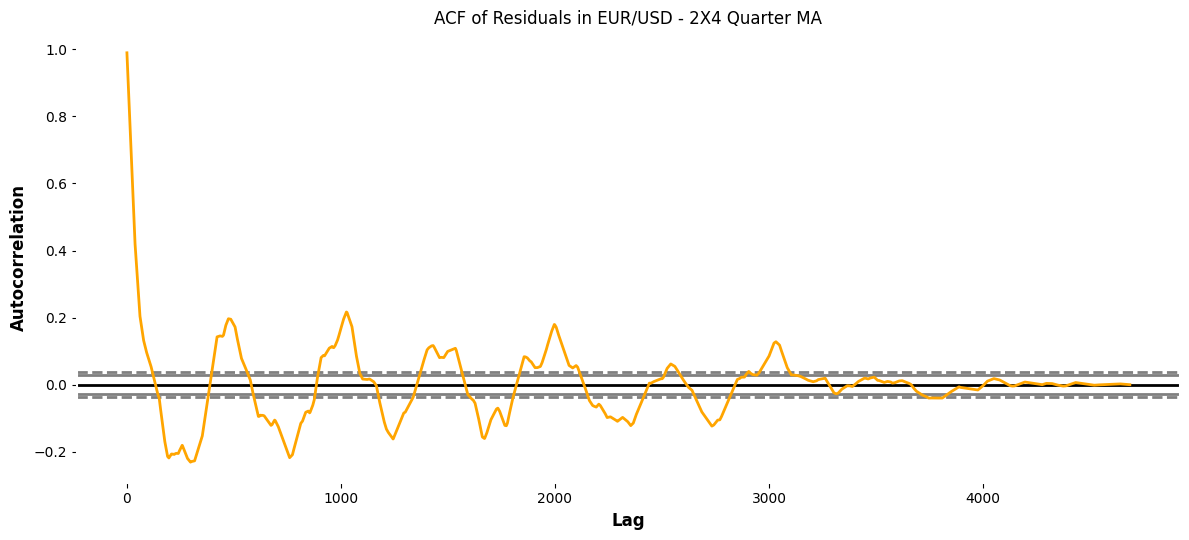

In [68]:
fig = plt.figure(figsize=(12, 5.5))
ax = fig.add_subplot(1,1,1)
autocorrelation_plot(residuals.iloc[:8000], ax=ax, color='orange')
ax.set_title('ACF of Residuals in EUR/USD - 2X4 Quarter MA')
plt.tight_layout()
plt.show()

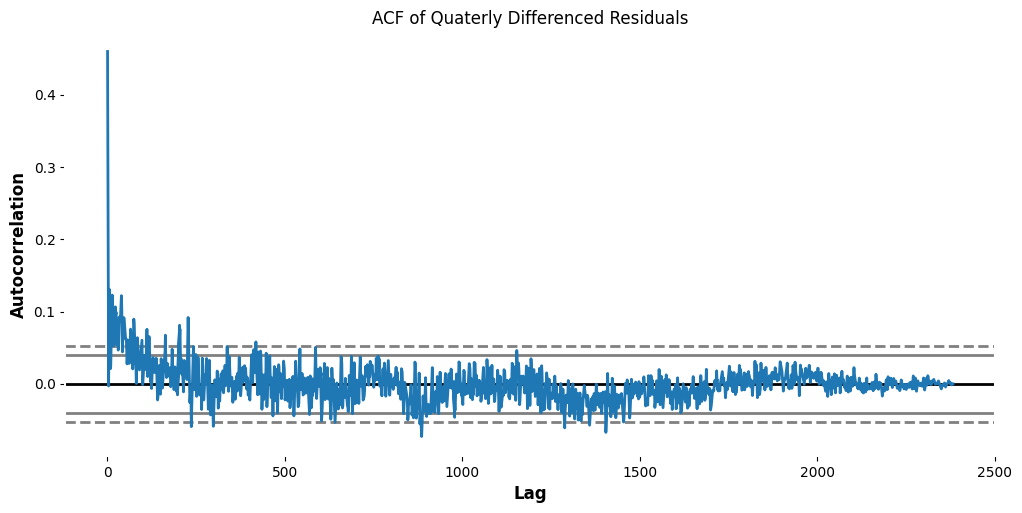

In [69]:
residuals_qtr_diff = np.log(residuals.diff(4))
residuals_qtr_diff = residuals_qtr_diff.loc[~pd.isnull(residuals_qtr_diff)]
fig = plt.figure(figsize=(12, 5.5))
ax = fig.add_subplot(1,1,1)
autocorrelation_plot(residuals_qtr_diff, ax=ax)
ax.set_title('ACF of Quaterly Differenced Residuals');

In [70]:
_, _, _, pval_monthly_mean = stattools.acf(residuals_qtr_diff,
                                           nlags=10, 
                                           qstat=True, 
                                           alpha=0.05)
print('Null hypothesis is rejected for lags:', np.where(pval_monthly_mean<=0.05))

Null hypothesis is rejected for lags: (array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=int64),)


### **2.16. Media móvil ponderada**


 #### **2.16.1. Descomposición de series temporales mediante medias móviles**

#### **2.16.2. Modelo Aditivo**

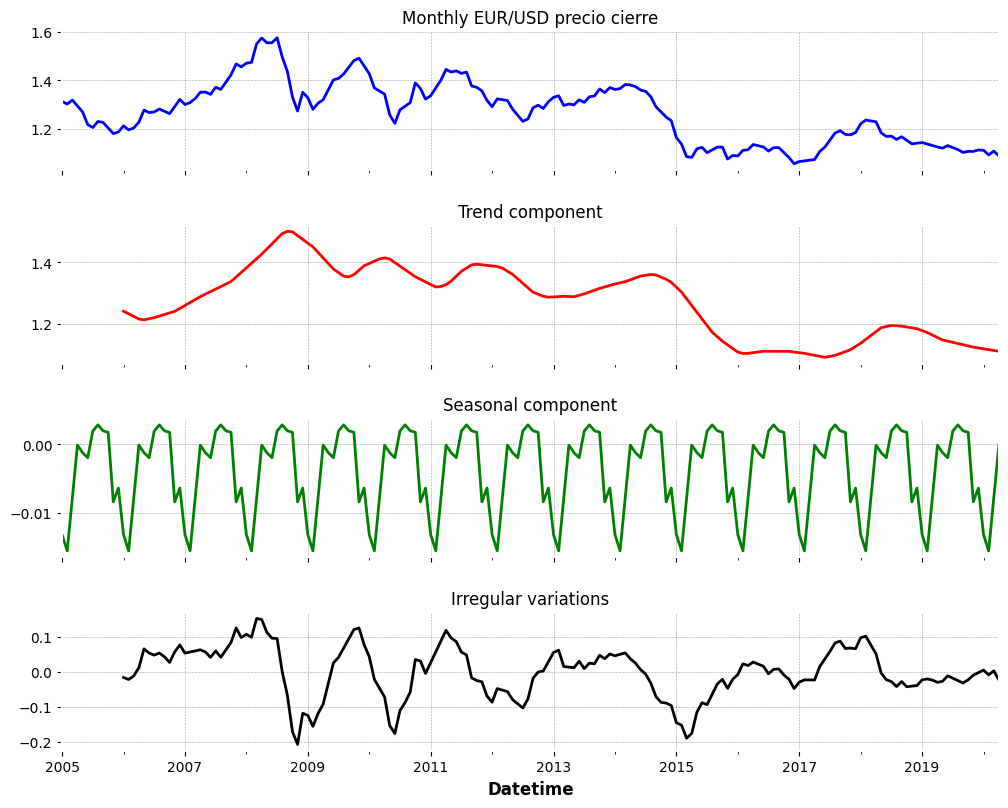

In [71]:
# Media móvil anual (12 meses) sobre datos mensuales
MA12 = monthly_mean_bc.rolling(window=12).mean()
trendComp = MA12.rolling(window=2).mean()

# Residuos = serie original - tendencia
residuals_add = monthly_mean_bc - trendComp

# Componente estacional - promedio por mes
df_add = pd.DataFrame({'Price': monthly_mean_bc, 'trendComp': trendComp, 'residuals': residuals_add})
df_add['Month'] = df_add.index.month

monthwise_avg = residuals_add.groupby(df_add['Month']).aggregate(['mean'])
nb_years = 2020 - 2005 + 1

seasonalComp = np.array([monthwise_avg.values] * nb_years).reshape((12 * nb_years,))
seasonalComp = seasonalComp[:len(monthly_mean_bc)]
seasonalComp = pd.Series(data=seasonalComp, index=monthly_mean_bc.index)

# Variaciones irregulares
irr_var = monthly_mean_bc - trendComp - seasonalComp

# Grafica
fig, axarr = plt.subplots(4, sharex=True)
fig.set_size_inches(10, 8)

monthly_mean_bc.plot(ax=axarr[0], color='b', linestyle='-')
axarr[0].set_title('Monthly EUR/USD precio cierre')

pd.Series(data=trendComp.values, index=monthly_mean_bc.index).plot(ax=axarr[1], color='r', linestyle='-')
axarr[1].set_title('Trend component')

seasonalComp.plot(ax=axarr[2], color='g', linestyle='-')
axarr[2].set_title('Seasonal component')

irr_var.plot(ax=axarr[3], color='k', linestyle='-')
axarr[3].set_title('Irregular variations')

plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=2.0)
plt.show()

In [72]:
adf_result = stattools.adfuller(irr_var.loc[~pd.isnull(irr_var)], autolag='AIC')
print('p-val of the ADF test on irregular variations in air miles flown:', adf_result[1])

p-val of the ADF test on irregular variations in air miles flown: 0.0005072387964558758


### **2.17. Modelo Multiplicativo**

In [73]:
residuals = monthly_mean_bc/ trendComp



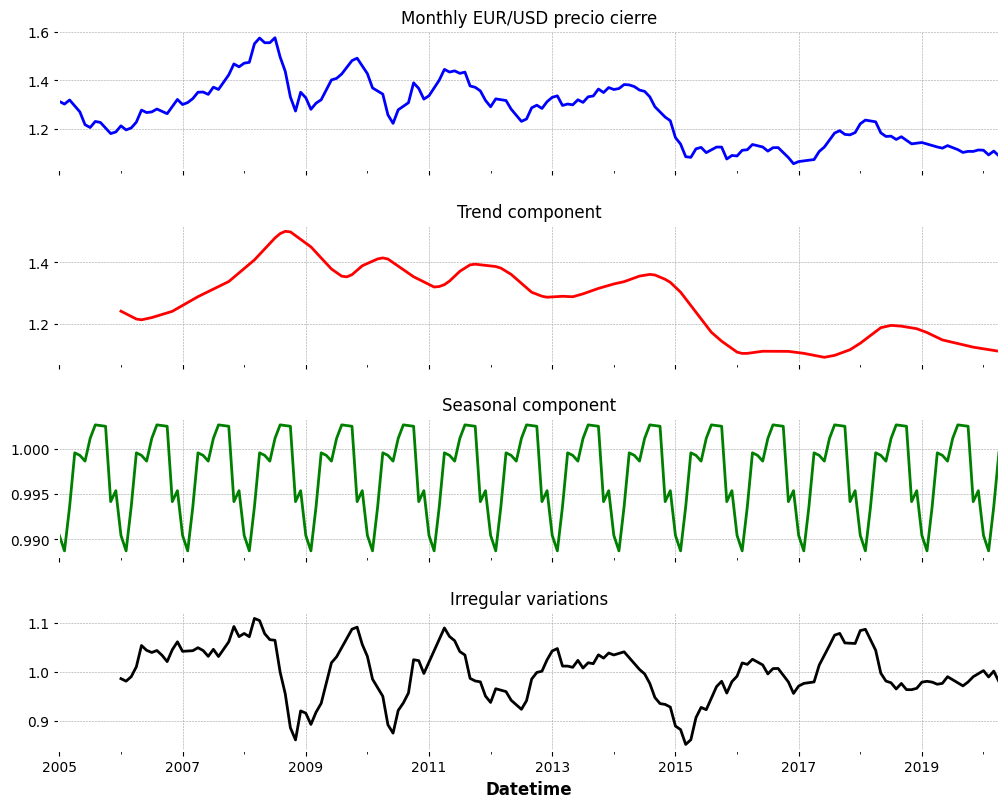

In [74]:
# Media móvil anual (12 meses) sobre datos mensuales
MA12 = monthly_mean_bc.rolling(window=12).mean()
trendComp = MA12.rolling(window=2).mean()

# Residuos multiplicativos
residuals_mult = monthly_mean_bc / trendComp

# Componente estacional
df_mult = pd.DataFrame({'Price': monthly_mean_bc, 'trendComp': trendComp, 'residuals': residuals_mult})
df_mult['Month'] = df_mult.index.month

monthwise_avg = residuals_mult.groupby(df_mult['Month']).aggregate(['mean'])
nb_years = 2020 - 2005 + 1

seasonalComp = np.array([monthwise_avg.values] * nb_years).reshape((12 * nb_years,))
seasonalComp = seasonalComp[:len(monthly_mean_bc)]
seasonalComp = pd.Series(data=seasonalComp, index=monthly_mean_bc.index)

# Variaciones irregulares
irr_var = monthly_mean_bc / (trendComp * seasonalComp)


# Grafica
fig, axarr = plt.subplots(4, sharex=True)
fig.set_size_inches(10, 8)

monthly_mean_bc.plot(ax=axarr[0], color='b', linestyle='-')
axarr[0].set_title('Monthly EUR/USD precio cierre')

pd.Series(data=trendComp.values, index=monthly_mean_bc.index).plot(ax=axarr[1], color='r', linestyle='-')
axarr[1].set_title('Trend component')

seasonalComp.plot(ax=axarr[2], color='g', linestyle='-')
axarr[2].set_title('Seasonal component')

pd.Series(data=irr_var.values, index=monthly_mean_bc.index).plot(ax=axarr[3], color='k', linestyle='-')
axarr[3].set_title('Irregular variations')

plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=2.0)
plt.show()

Descomposición de series temporales mediante statsmodels.tsa

In [75]:
import pandas as pd
import numpy as np
from statsmodels.tsa import stattools
from statsmodels.tsa import seasonal
from matplotlib import pyplot as plt

### **2.18. Modelo Mensual Aditivo**

In [77]:
adf_result = stattools.adfuller(monthly_mean_bc.dropna(), autolag='AIC')
print('p-val of the ADF test on EUR/USD monthly BC:', adf_result[1])

p-val of the ADF test on EUR/USD monthly BC: 0.561217675632001


In [78]:
decompose_model = seasonal.seasonal_decompose(monthly_mean_bc.tolist(), period=12, model='additive')

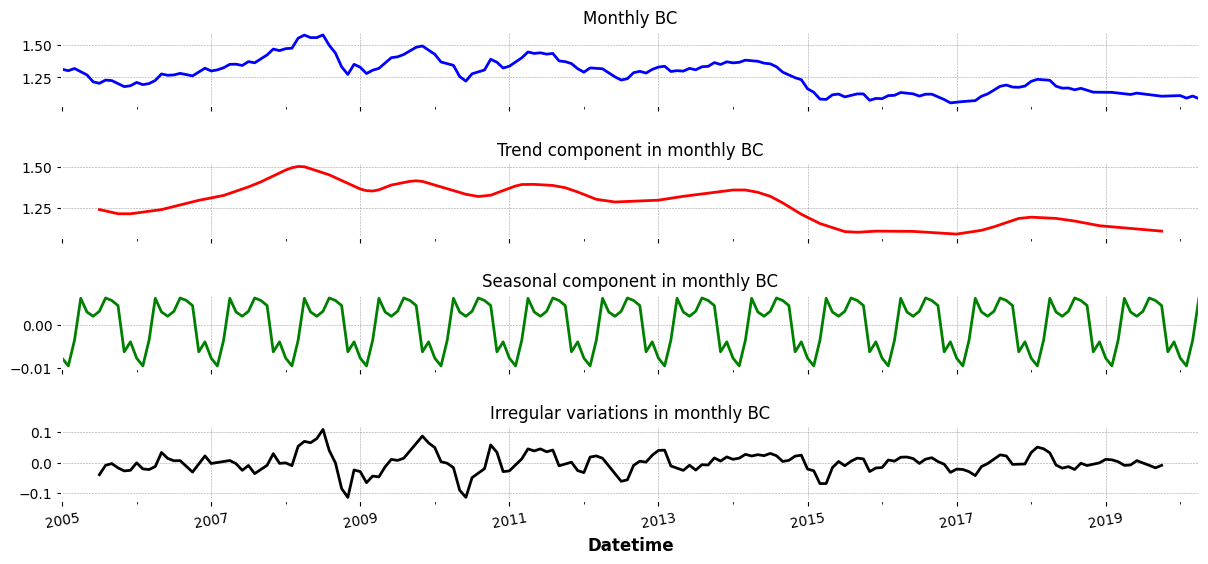

In [79]:
fig, axarr = plt.subplots(4, sharex=True)
fig.set_size_inches(12, 5.5)

monthly_mean_bc.plot(ax=axarr[0], color='b', linestyle='-')
axarr[0].set_title('Monthly BC')

pd.Series(data=decompose_model.trend, index=monthly_mean_bc.index).plot(color='r', linestyle='-', ax=axarr[1])
axarr[1].set_title('Trend component in monthly BC')

pd.Series(data=decompose_model.seasonal, index=monthly_mean_bc.index).plot(color='g', linestyle='-', ax=axarr[2])
axarr[2].set_title('Seasonal component in monthly BC')

pd.Series(data=decompose_model.resid, index=monthly_mean_bc.index).plot(color='k', linestyle='-', ax=axarr[3])
axarr[3].set_title('Irregular variations in monthly BC')

plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=2.0);
plt.xticks(rotation=10);

In [80]:
adf_result = stattools.adfuller(decompose_model.resid[np.where(np.isfinite(decompose_model.resid))[0]], 
                                autolag='AIC')
print('p-val of the ADF test on irregular variations in BC:', adf_result[1])

p-val of the ADF test on irregular variations in BC: 1.0795039426489074e-09


### **2.19. Modelo Mensual Multiplicativo**

In [81]:
decompose_model = seasonal_decompose(monthly_mean_bc.tolist(), period=12, model='multiplicative')

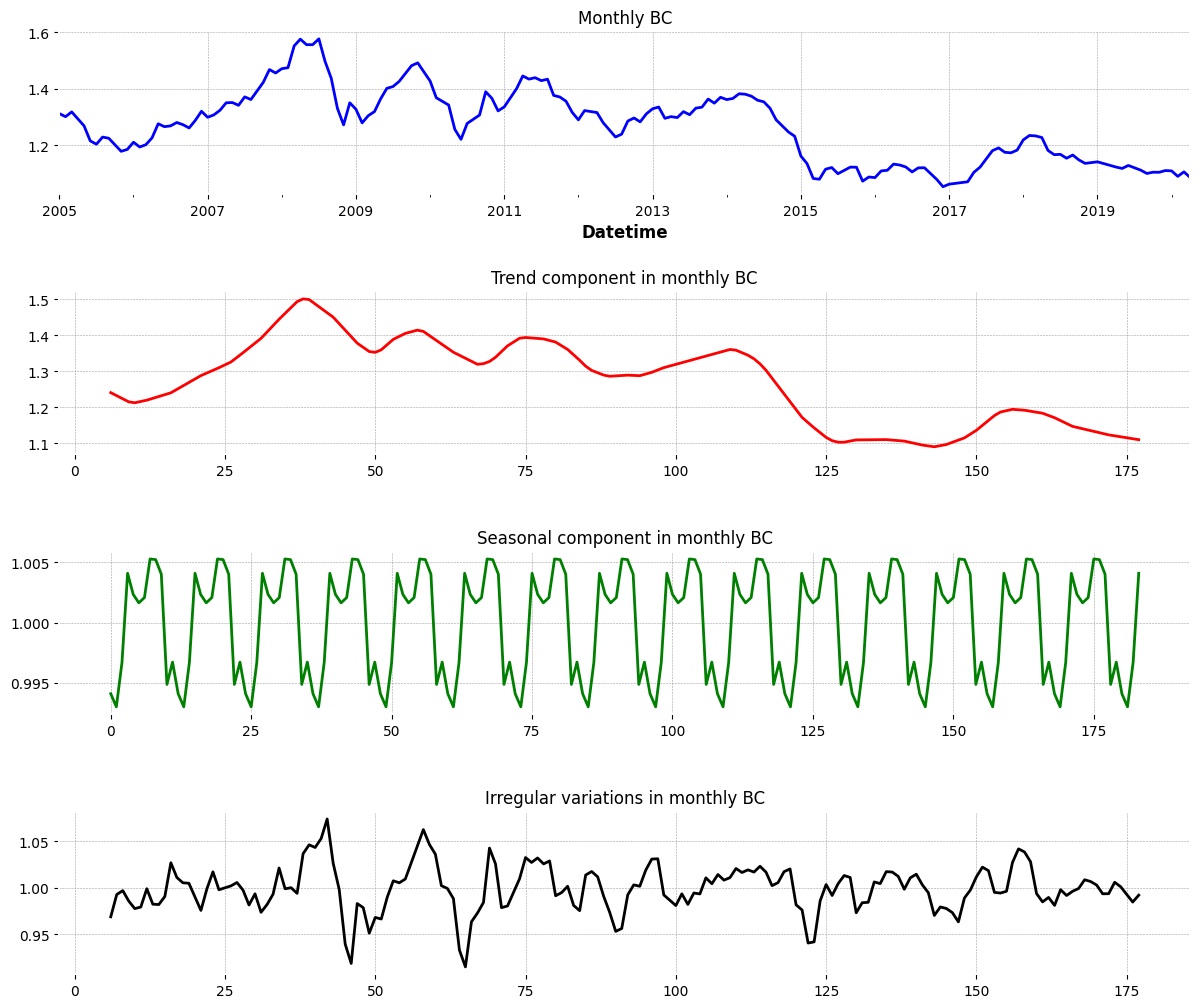

In [82]:
fig, axarr = plt.subplots(4, sharex=False)
fig.set_size_inches(12, 10)

monthly_mean_bc.plot(ax=axarr[0], color='b', linestyle='-')
axarr[0].set_title('Monthly BC')

axarr[1].plot(decompose_model.trend, color='r', linestyle='-')
axarr[1].set_title('Trend component in monthly BC')

axarr[2].plot(decompose_model.seasonal, color='g', linestyle='-')
axarr[2].set_title('Seasonal component in monthly BC')

axarr[3].plot(decompose_model.resid, color='k', linestyle='-')
axarr[3].set_title('Irregular variations in monthly BC')

plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=2.0)
plt.show()

In [83]:
adf_result = stattools.adfuller(decompose_model.resid[np.where(np.isfinite(decompose_model.resid))[0]], 
                                autolag='AIC')
print('p-val of the ADF test on irregular variations in BC data:', adf_result[1])

p-val of the ADF test on irregular variations in BC data: 1.8201905072509565e-09


### **2.20. Modelo Diario Aditivo**

In [84]:
adf_result = stattools.adfuller(bc_daily_ma.dropna(), autolag='AIC')
print('p-val of the ADF test on EUR/USD daily BC:', adf_result[1])

p-val of the ADF test on EUR/USD daily BC: 0.45214138760073985


In [85]:
decompose_model = seasonal.seasonal_decompose(bc_daily_ma.tolist(), period=12, model='additive')

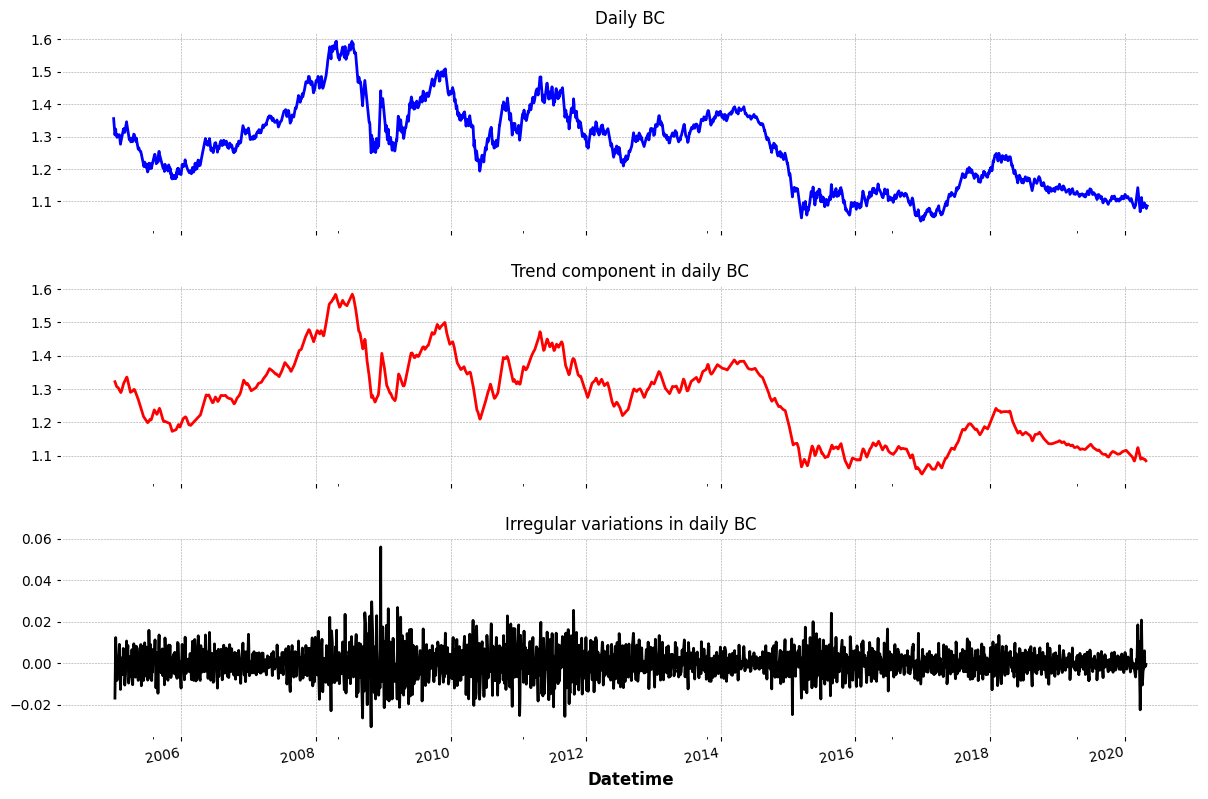

In [86]:

fig, axarr = plt.subplots(3, sharex=True)
fig.set_size_inches(12, 8)

bc_daily_ma.plot(ax=axarr[0], color='b', linestyle='-')
axarr[0].set_title('Daily BC')

pd.Series(data=decompose_model.trend, index=bc_daily_ma.index).plot(color='r', linestyle='-', ax=axarr[1])
axarr[1].set_title('Trend component in daily BC')

pd.Series(data=decompose_model.resid, index=bc_daily_ma.index).plot(color='k', linestyle='-', ax=axarr[2])
axarr[2].set_title('Irregular variations in daily BC')

plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=2.0)
plt.xticks(rotation=10)
plt.show()

In [87]:
adf_result = stattools.adfuller(decompose_model.resid[np.where(np.isfinite(decompose_model.resid))[0]], 
                                autolag='AIC')
print('p-val of the ADF test on irregular variations in BC daily:', adf_result[1])

p-val of the ADF test on irregular variations in BC daily: 2.0223184428482038e-30


### **2.21. Modelo Diario Multiplicativo**

In [88]:
decompose_model = seasonal_decompose(bc_daily_ma.tolist(), period=12, model='multiplicative')

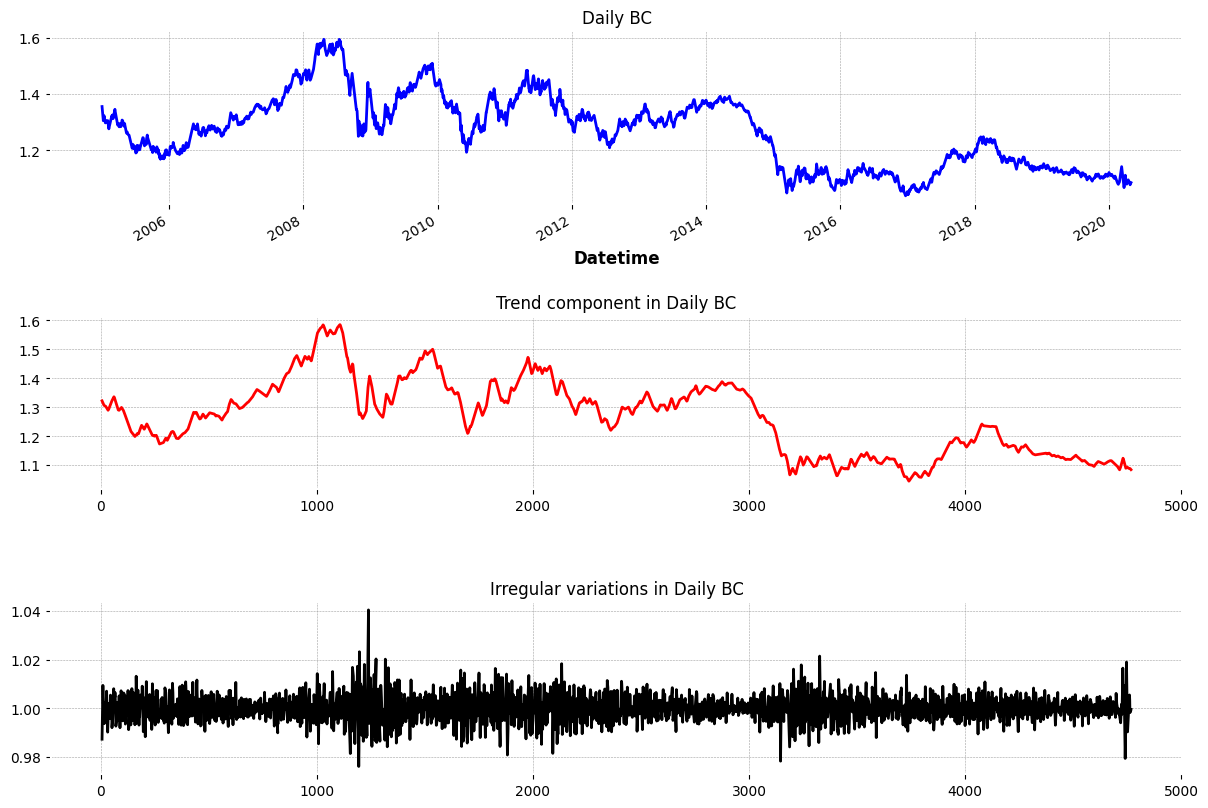

In [90]:
fig, axarr = plt.subplots(3, sharex=False)
fig.set_size_inches(12, 8)

bc_daily_ma.plot(ax=axarr[0], color='b', linestyle='-')
axarr[0].set_title('Daily BC')

axarr[1].plot(decompose_model.trend, color='r', linestyle='-')
axarr[1].set_title('Trend component in Daily BC')

axarr[2].plot(decompose_model.resid, color='k', linestyle='-')
axarr[2].set_title('Irregular variations in Daily BC')

plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=2.0)
plt.show()

Bibliografía

European Central Bank. (2014, 27 noviembre). Estabilidad y prosperidad en la Unión Monetaria. https://www.ecb.europa.eu/press/key/date/2014/html/sp141127_1.es.html

Figal, A. G. (2021). Pronóstico de la tasa de cambio euro-dólar. Diagnóstico de técnicas predictivas. ECA Sinergia, 12(3), 7-17.

Montoya Zapata, C., & Corredor Roa, C. A. (2022). Aplicación de modelos de deep learning y machine learning para el pronóstico de la serie de tiempo del par de divisas Euro-Dólar.

Welle, D. (2020, 29 abril). FED: contracción económica en EE.UU. no tendrá precedentes. dw.com. https://www.dw.com/es/fed-contracci%C3%B3n-econ%C3%B3mica-en-eeuu-no-tendr%C3%A1-precedentes/a-53286099



